In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import mannwhitneyu, norm
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import kendalltau
from scipy.stats import kruskal
from scipy.stats import anderson
from scipy.stats import levene

import plotly.graph_objects as go
rng = np.random.default_rng()
#x = stats.uniform.rvs(size=75, random_state=rng)
sns.set(style="darkgrid")

In [ ]:
#
df_bancos = pd.read_csv(r'Banking_Transactions_USA_2023_2024.csv')
print(f'Columnas totales: {len(df_bancos.columns)}')
print()
print('Lista de columnas:')
for i, col in enumerate(df_bancos.columns, 1):
    print(f'  {i:>2}. {col}')

Columnas totales: 20

Lista de columnas:
   1. Transaction_ID
   2. Account_Number
   3. Transaction_Date
   4. Transaction_Amount
   5. Merchant_Name
   6. Transaction_Type
   7. Category
   8. City
   9. Country
  10. Payment_Method
  11. Customer_Age
  12. Customer_Gender
  13. Customer_Occupation
  14. Customer_Income
  15. Account_Balance
  16. Transaction_Status
  17. Fraud_Flag
  18. Discount_Applied
  19. Loyalty_Points_Earned
  20. Transaction_Description


In [ ]:
#
df_bancos = pd.read_csv(r'Banking_Transactions_USA_2023_2024.csv')
mb_full = df_bancos.memory_usage(deep=True).sum() / 1024**2
print(f'Dataset completo: {df_bancos.shape} · {mb_full:.1f} MB')
print()

# Perfil de cada columna: tipo, NaN%, valores unicos
print(f'{"Columna":<30} {"Dtype":<12} {"NaN%":>7} {"Unicos":>8}')
print('-' * 65)
for col in df_bancos.columns:
    dtype = str(df_bancos[col].dtype)
    nan_pct = df_bancos[col].isna().mean() * 100
    n_uniq  = df_bancos[col].nunique()
    print(f'{col:<30} {dtype:<12} {nan_pct:>6.1f}% {n_uniq:>8,}')

Dataset completo: (5389, 20) · 5.3 MB

Columna                        Dtype           NaN%   Unicos
-----------------------------------------------------------------
Transaction_ID                 object          0.0%    5,389
Account_Number                 object          0.0%    5,389
Transaction_Date               object          0.0%    5,389
Transaction_Amount             float64         0.0%    5,369
Merchant_Name                  object          0.0%    4,880
Transaction_Type               object          0.0%        2
Category                       object          0.0%       14
City                           object          0.0%       10
Country                        object          0.0%        1
Payment_Method                 object          0.0%        5
Customer_Age                   int64           0.0%       53
Customer_Gender                object          0.0%        3
Customer_Occupation            object          0.0%      639
Customer_Income                float64   

In [60]:
#

df_bancos.head()

,Transaction_ID,Account_Number,Transaction_Date,Transaction_Amount,Merchant_Name,Transaction_Type,Category,City,Country,Payment_Method,Customer_Age,Customer_Gender,Customer_Occupation,Customer_Income,Account_Balance,Transaction_Status,Fraud_Flag,Discount_Applied,Loyalty_Points_Earned,Transaction_Description
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,IUPM04409079772781,2023-11-05 15:54:38,3198.94,Houston Group,Debit,Transport,Phoenix,USA,Online Transfer,55,Others,Quality manager,80466.03,350.28,Failed,No,True,304,Recently company detail form range a.
1,23b8c1e9-3924-46de-beb1-3b9046685257,BLAT22216107051843,2024-04-21 22:21:55,129.93,Anderson-Phillips,Credit,Grocery,Philadelphia,USA,Debit Card,26,Others,Civil Service fast streamer,145574.25,9797.81,Pending,Yes,False,383,Anything son baby power heart will not up.
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,UTXA55295806601382,2023-07-17 13:25:56,1378.77,Jensen Group,Credit,Shopping,New York,USA,Debit Card,29,Others,"Pilot, airline",33447.18,12399.85,Failed,Yes,False,497,Form world around green bar environment pattern.
3,972a8469-1641-4f82-8b9d-2434e465e150,XICF70493862044851,2023-06-27 16:09:52,1119.94,"Nelson, Gomez and Rodriguez",Credit,Healthcare,Dallas,USA,Online Transfer,60,Male,"Radiographer, therapeutic",108801.45,16057.64,Failed,Yes,True,495,Order evening source these opportunity trade i...
4,17fc695a-07a0-4a6e-8822-e8f36c031199,KOSW19711121259020,2024-03-26 23:45:31,3683.67,Caldwell Group,Credit,Entertainment,San Jose,USA,E-Wallet,29,Others,Diplomatic Services operational officer,100985.12,14940.54,Failed,Yes,True,292,Exactly politics door suggest.


In [61]:
# 

df_bancos.tail()

,Transaction_ID,Account_Number,Transaction_Date,Transaction_Amount,Merchant_Name,Transaction_Type,Category,City,Country,Payment_Method,Customer_Age,Customer_Gender,Customer_Occupation,Customer_Income,Account_Balance,Transaction_Status,Fraud_Flag,Discount_Applied,Loyalty_Points_Earned,Transaction_Description
5384,31e43850-86a8-4b2b-9c69-ee49712c3126,LXVL92532425475957,2023-05-01 07:20:11,842.16,Navarro Group,Credit,Savings,Phoenix,USA,Cash,20,Male,"Loss adjuster, chartered",75036.50,8747.79,Pending,Yes,True,332,Sit could account happen organization hand act...
5385,5415668e-4f75-43d1-9610-7189016ff44c,MFJS29896187528828,2023-09-15 03:49:42,1996.73,Banks-Reed,Credit,Travel,Phoenix,USA,Credit Card,28,Male,Accommodation manager,107479.71,2698.54,Failed,Yes,True,60,Soldier per crime nothing improve structure ow...
5386,ea725584-5e6e-487a-a939-f79018177e4a,DOBF62458522431672,2024-11-30 00:58:14,1510.33,Brown PLC,Debit,Utilities,Dallas,USA,Credit Card,23,Male,"Administrator, education",33759.96,476.93,Success,No,True,475,Magazine reality share office doctor managemen...
5387,03539b9a-ebeb-4d98-80b7-10a640f66fde,BRHX88846108622659,2023-08-09 00:31:15,3732.02,Townsend-Bartlett,Debit,Savings,Chicago,USA,Cash,40,Female,Music therapist,32706.74,7167.05,Success,Yes,True,482,Probably ago western approach.
5388,a5b01639-0895-4db1-85e5-26e19b559178,CTJA66942505562975,2024-03-16 09:44:09,3763.38,"Molina, Smith and King",Debit,Utilities,Houston,USA,Debit Card,38,Male,Structural engineer,106270.94,2197.74,Success,Yes,False,152,Social suddenly lead.


In [62]:
# 

resumen_numericas = df_bancos.describe()
resumen_numericas

,Transaction_Amount,Customer_Age,Customer_Income,Account_Balance,Loyalty_Points_Earned
count,5389.000000,5389.000000,5389.000000,5389.000000,5389.000000
mean,2504.649200,44.023567,85802.754023,10096.510087,249.897384
std,1426.745115,15.239148,37343.604534,5732.846891,145.378373
min,5.460000,18.000000,20028.940000,101.720000,0.000000
25%,1283.340000,31.000000,53809.800000,5159.450000,122.000000
50%,2521.670000,44.000000,85636.380000,10077.780000,251.000000
75%,3715.920000,57.000000,118092.640000,15076.010000,377.000000
max,4999.540000,70.000000,149970.500000,19993.040000,500.000000


In [63]:
#

resumen_discretas = df_bancos.describe(include='object')
resumen_discretas

,Transaction_ID,Account_Number,Transaction_Date,Merchant_Name,Transaction_Type,Category,City,Country,Payment_Method,Customer_Gender,Customer_Occupation,Transaction_Status,Fraud_Flag,Transaction_Description
count,5389,5389,5389,5389,5389,5389,5389,5389,5389,5389,5389,5389,5389,5389
unique,5389,5389,5389,4880,2,14,10,1,5,3,639,3,2,5389
top,bdd640fb-0667-4ad1-9c80-317fa3b1799d,IUPM04409079772781,2023-11-05 15:54:38,Smith LLC,Debit,Utilities,Chicago,USA,E-Wallet,Female,Child psychotherapist,Pending,No,Recently company detail form range a.
freq,1,1,1,10,2708,417,589,5389,1100,1824,18,1811,2732,1


In [64]:
# 
resumen_estatus = pd.DataFrame({
    'Total Transacciones': df_bancos['Transaction_Status'].value_counts(),
    'Proporción de la Cartera': df_bancos['Transaction_Status'].value_counts(normalize=True) * 100
})

print("VISTA GENERAL - ESTATUS OPERATIVO DE LAS TRANSACCIONES")
resumen_estatus.style.format({
    'Total Transacciones': '{:,.0f}', 
    'Proporción de la Cartera': '{:.2f}%'
})


VISTA GENERAL - ESTATUS OPERATIVO DE LAS TRANSACCIONES


,Total Transacciones,Proporción de la Cartera
Transaction_Status,,
Pending,"1,811",33.61%
Failed,"1,789",33.20%
Success,"1,789",33.20%


In [65]:
print("""
==============================================================================
CONCLUSIONES \nESTATUS OPERATIVO DE LAS TRANSACCIONES
==============================================================================
  Hallazgo de Negocio
  Las transacciones se dividen de manera casi exacta en tres tercios: 
      33.20% Fallidas (Failed), 
      33.20% Pendientes (Pending) y 
      33.20% Exitosas (Successful)
""")


CONCLUSIONES 
ESTATUS OPERATIVO DE LAS TRANSACCIONES
  Hallazgo de Negocio
  Las transacciones se dividen de manera casi exacta en tres tercios: 
      33.20% Fallidas (Failed), 
      33.20% Pendientes (Pending) y 
      33.20% Exitosas (Successful)



In [66]:
# transacciones y montos por ciudad
resumen_ciudades = df_bancos.groupby('City')['Transaction_Amount'].agg(['count', 'sum', 'mean'])
resumen_ciudades = resumen_ciudades.sort_values(by='count', ascending=False)

print("VISTA GENERAL - CONCENTRACIÓN GEOGRÁFICA DE LA CARTERA")
resumen_ciudades.style.format({"sum": "${:,.2f}", "mean": "${:,.2f}", "count": "{:,.0f}"})


VISTA GENERAL - CONCENTRACIÓN GEOGRÁFICA DE LA CARTERA


,count,sum,mean
City,,,
Chicago,589,"$1,463,028.14","$2,483.92"
New York,565,"$1,368,804.35","$2,422.66"
San Jose,555,"$1,435,622.81","$2,586.71"
Los Angeles,554,"$1,424,179.66","$2,570.72"
San Antonio,548,"$1,381,909.27","$2,521.73"
Dallas,545,"$1,382,739.67","$2,537.14"
Houston,525,"$1,284,925.18","$2,447.48"
Phoenix,513,"$1,264,166.46","$2,464.26"
Philadelphia,508,"$1,290,232.27","$2,539.83"


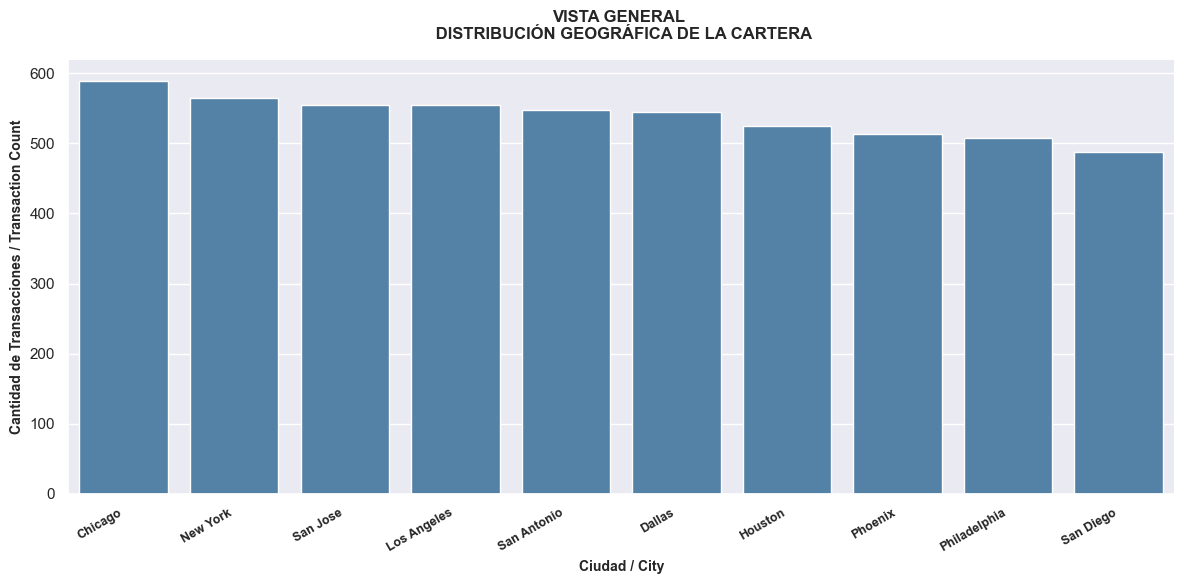

In [67]:
#
# 
plt.figure(figsize=(12, 6))

#
orden_ciudades = df_bancos['City'].value_counts().index
sns.countplot(data=df_bancos, x="City", order=orden_ciudades, color="#4682B4")

#
plt.title('VISTA GENERAL \n DISTRIBUCIÓN GEOGRÁFICA DE LA CARTERA', 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Ciudad / City', fontsize=10, fontweight='bold')
plt.ylabel('Cantidad de Transacciones / Transaction Count', fontsize=10, fontweight='bold')

#
plt.xticks(rotation=30, ha='right', fontsize=9, fontweight='bold')

#
sns.despine()

plt.tight_layout()
plt.show()



In [68]:
#
balances_ordenados = df_bancos['Account_Balance'].sort_values(ascending=False)

# clientes que representan el 20% superior de la cartera
top_20_clientes = int(len(balances_ordenados) * 0.20)

# proporción de capital acumulado en ese grupo VIP
capital_total = balances_ordenados.sum()
capital_top_20 = balances_ordenados.iloc[:top_20_clientes].sum()
pct_concentracion = (capital_top_20 / capital_total) * 100

#
print("VISTA GENERAL - CONCENTRACIÓN DE CAPITAL")
print("=" * 75)
print(f"   Total de clientes en la cartera : {len(df_bancos):,}")
print(f"   Segmento 20% Superior           : {top_20_clientes:,} clientes")
print(f"   Concentración de Capital        : {pct_concentracion:.2f}%")



VISTA GENERAL - CONCENTRACIÓN DE CAPITAL
   Total de clientes en la cartera : 5,389
   Segmento 20% Superior           : 1,077 clientes
   Concentración de Capital        : 35.58%


In [69]:
print("""
==============================================================================
CONCLUSIONES \nCONCENTRACIÓN DE CAPITAL
==============================================================================
  Hallazgo de Negocio 
  El 20% de los clientes con los saldos más altos acumula 
  únicamente el 35.58% del capital total de la cartera transaccional.
""")



CONCLUSIONES 
CONCENTRACIÓN DE CAPITAL
  Hallazgo de Negocio 
  El 20% de los clientes con los saldos más altos acumula 
  únicamente el 35.58% del capital total de la cartera transaccional.



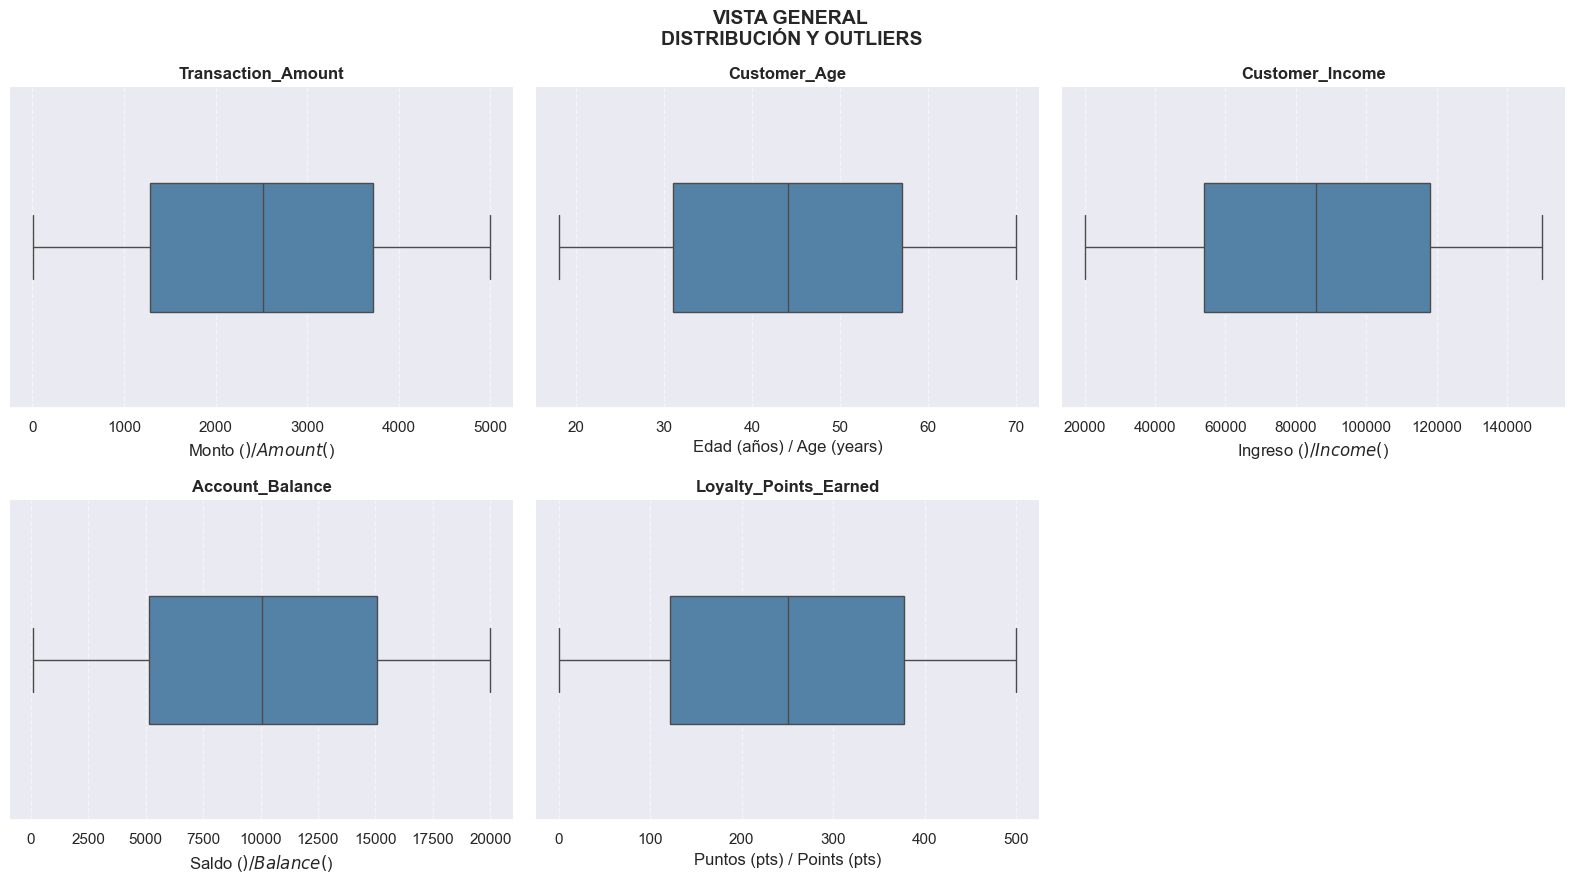

In [70]:

# 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('VISTA GENERAL \nDISTRIBUCIÓN Y OUTLIERS', 
             fontsize=14, fontweight='bold', y=0.98)

#
color_grafica = "#4682B4" 

#
sns.boxplot(data=df_bancos, x="Transaction_Amount", ax=axes[0, 0], color=color_grafica, width=0.4)
axes[0, 0].set_title("Transaction_Amount", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Monto ($) / Amount ($)")

sns.boxplot(data=df_bancos, x="Customer_Age", ax=axes[0, 1], color=color_grafica, width=0.4)
axes[0, 1].set_title("Customer_Age", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Edad (años) / Age (years)")

sns.boxplot(data=df_bancos, x="Customer_Income", ax=axes[0, 2], color=color_grafica, width=0.4)
axes[0, 2].set_title("Customer_Income", fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel("Ingreso ($) / Income ($)")

sns.boxplot(data=df_bancos, x="Account_Balance", ax=axes[1, 0], color=color_grafica, width=0.4)
axes[1, 0].set_title("Account_Balance", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Saldo ($) / Balance ($)")

sns.boxplot(data=df_bancos, x="Loyalty_Points_Earned", ax=axes[1, 1], color=color_grafica, width=0.4)
axes[1, 1].set_title("Loyalty_Points_Earned", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Puntos (pts) / Points (pts)")

#
axes[1, 2].axis("off")

#
for i in range(2):
    for j in range(3):
        if not (i == 1 and j == 2):
            sns.despine(ax=axes[i, j], left=True)
            axes[i, j].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [71]:
print("""
==============================================================================
CONCLUSIONES \nVALORES ATÍPICOS
==============================================================================
  Hallazgo de Negocio
  Las medianas de las 5 variables numéricas se ubican exactamente en el centro 
  de las cajas y se detectan 0 registros atípicos (outliers).
""")



CONCLUSIONES 
VALORES ATÍPICOS
  Hallazgo de Negocio
  Las medianas de las 5 variables numéricas se ubican exactamente en el centro 
  de las cajas y se detectan 0 registros atípicos (outliers).



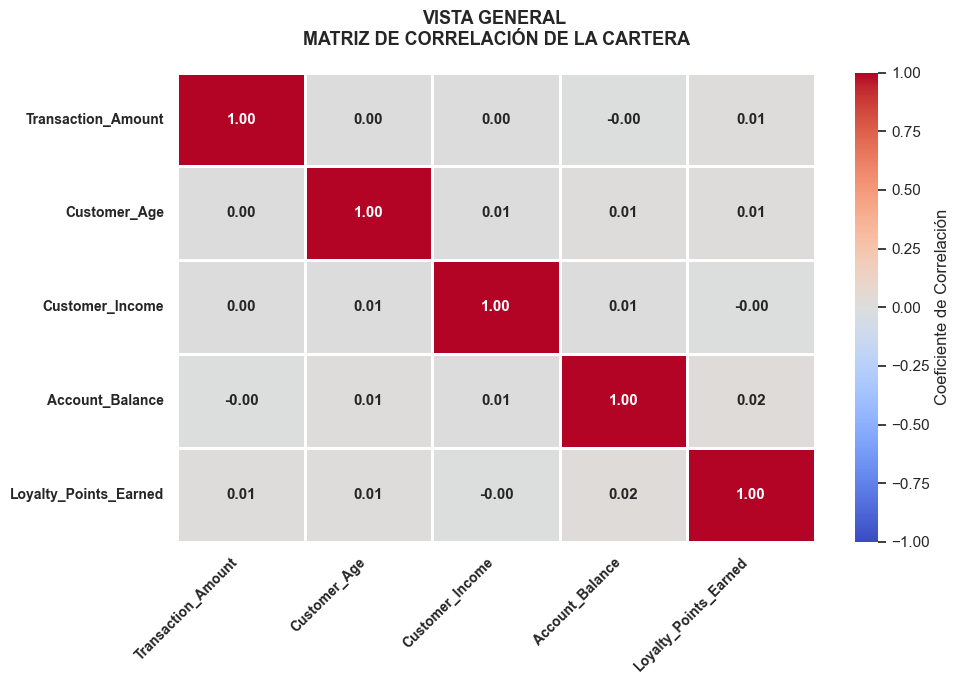

In [72]:

# correlación de Spearman para las 5 variables cuantitativas
columnas_num = ['Transaction_Amount', 'Customer_Age', 'Customer_Income', 'Account_Balance', 'Loyalty_Points_Earned']
df_bancos_corr = df_bancos[columnas_num].corr(method='spearman')

#
plt.figure(figsize=(10, 7))

# Graficar el mapa de calor
sns.heatmap(
    df_bancos_corr, 
    annot=True,              
    cmap='coolwarm',         
    fmt=".2f",               
    linewidths=0.8,          
    vmin=-1, vmax=1,        
    cbar_kws={"label": "Coeficiente de Correlación"}, 
    square=False,            
    annot_kws={"size": 11, "fontweight": "bold"} 
)

#
plt.title('VISTA GENERAL \nMATRIZ DE CORRELACIÓN DE LA CARTERA', 
          fontsize=13, fontweight='bold', pad=20)

# 
plt.xticks(rotation=45, ha='right', fontsize=10, fontweight='bold')
plt.yticks(rotation=0, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


In [73]:
print("""
==============================================================================
CONCLUSIONES \nANÁLISIS DE CORRELACIÓN 
==============================================================================
  Hallazgo de Negocio
  Todos los coeficientes de correlación fuera de la diagonal principal arrojan 
  valores nulos o cercanos a cero (0.00, 0.01, 0.02).
""")



CONCLUSIONES 
ANÁLISIS DE CORRELACIÓN 
  Hallazgo de Negocio
  Todos los coeficientes de correlación fuera de la diagonal principal arrojan 
  valores nulos o cercanos a cero (0.00, 0.01, 0.02).



In [74]:
#
percentiles = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

# percentiles para las 5 columnas numéricas
columnas_num = ['Transaction_Amount', 'Customer_Age', 'Customer_Income', 'Account_Balance', 'Loyalty_Points_Earned']
df_bancos_percentiles = df_bancos[columnas_num].quantile(percentiles)

# 
df_bancos_percentiles.index = [
    'Percentil 10 (P10)', 'Percentil 20 (P20)', 'Percentil 30 (P30)',
    'Percentil 40 (P40)', 'Percentil 50 (P50)', 'Percentil 60 (P60)',
    'Percentil 70 (P70)', 'Percentil 80 (P80)', 'Percentil 90 (P90)'
]

print("REPORTE PERCENTILES - VARIABLES NUMÉRICAS")

#
formatos_percentiles = {
    'Transaction_Amount': "${:,.2f}",
    'Customer_Income': "${:,.2f}",
    'Account_Balance': "${:,.2f}",
    'Customer_Age': "{:.1f}",
    'Loyalty_Points_Earned': "{:,.1f}"
}

df_bancos_percentiles.style.format(formatos_percentiles)


REPORTE PERCENTILES - VARIABLES NUMÉRICAS


,Transaction_Amount,Customer_Age,Customer_Income,Account_Balance,Loyalty_Points_Earned
Percentil 10 (P10),$519.45,23.0,"$33,445.10","$2,043.31",49.0
Percentil 20 (P20),"$1,017.71",28.0,"$47,541.39","$4,115.05",98.0
Percentil 30 (P30),"$1,519.80",33.0,"$60,243.90","$6,257.16",148.0
Percentil 40 (P40),"$2,019.48",39.0,"$73,394.66","$8,326.80",198.0
Percentil 50 (P50),"$2,521.67",44.0,"$85,636.38","$10,077.78",251.0
Percentil 60 (P60),"$3,013.97",49.0,"$99,216.63","$12,136.19",300.0
Percentil 70 (P70),"$3,480.21",55.0,"$111,758.55","$14,064.19",352.6
Percentil 80 (P80),"$3,967.22",60.0,"$124,205.44","$16,030.41",403.0
Percentil 90 (P90),"$4,476.50",65.0,"$137,448.35","$17,928.00",451.0


In [75]:
#
cuartiles = [0.25, 0.50, 0.75]

# cuartiles para las 5 columnas numéricas
columnas_numericas = ['Transaction_Amount', 'Customer_Age', 'Customer_Income', 'Account_Balance', 'Loyalty_Points_Earned']
df_bancos_cuartiles = df_bancos[columnas_numericas].quantile(cuartiles)

#
df_bancos_cuartiles.index = [
    'Cuartil 1 (Q1)',
    'Cuartil 2 (Q2/Mediana)',
    'Cuartil 3 (Q3)'
]

print("REPORTE CUARTILES - VARIABLES NUMÉRICAS")

#
formatos_cuartiles = {
    'Transaction_Amount': "${:,.2f}",
    'Customer_Income': "${:,.2f}",
    'Account_Balance': "${:,.2f}",
    'Customer_Age': "{:.1f}",
    'Loyalty_Points_Earned': "{:,.1f}"
}

df_bancos_cuartiles.style.format(formatos_cuartiles)


REPORTE CUARTILES - VARIABLES NUMÉRICAS


,Transaction_Amount,Customer_Age,Customer_Income,Account_Balance,Loyalty_Points_Earned
Cuartil 1 (Q1),"$1,283.34",31.0,"$53,809.80","$5,159.45",122.0
Cuartil 2 (Q2/Mediana),"$2,521.67",44.0,"$85,636.38","$10,077.78",251.0
Cuartil 3 (Q3),"$3,715.92",57.0,"$118,092.64","$15,076.01",377.0


In [76]:
# Rango Intercuartílico (IQR) para los Montos de Transacción
Q1 = df_bancos['Transaction_Amount'].quantile(0.25)
Q3 = df_bancos['Transaction_Amount'].quantile(0.75)
IQR = Q3 - Q1

# límites estadísticos de control
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar e identificar si existen transacciones atípicas
outliers = df_bancos[(df_bancos['Transaction_Amount'] < limite_inferior) | (df_bancos['Transaction_Amount'] > limite_superior)]

print("DIAGNÓSTICO DE VALORES ATÍPICOS (OUTLIERS) \nRANGO INTERCUANTIL")
print("=" * 75)
print(f"  Límite Inferior para considerar Outlier: ${limite_inferior:,.2f}")
print(f"  Límite Superior para considerar Outlier: ${limite_superior:,.2f}")
print(f"  Total de registros fuera de límites    : {len(outliers)}")


DIAGNÓSTICO DE VALORES ATÍPICOS (OUTLIERS) 
RANGO INTERCUANTIL
  Límite Inferior para considerar Outlier: $-2,365.53
  Límite Superior para considerar Outlier: $7,364.79
  Total de registros fuera de límites    : 0


In [77]:

# ENFOQUES ESPECÍFICOS - CREACIÓN DE SUBSET DE INTERÉS

#
subset_bancos = df_bancos.copy()

# limpiar espacios en blanco residuales en los nombres de las columnas
subset_bancos.columns = subset_bancos.columns.str.strip()

#
columnas_subset = [
    'Transaction_Amount', 
    'Transaction_Type', 
    'Customer_Age',
    'Customer_Gender',
    'Transaction_Status', 
    'Fraud_Flag', 
    'City'
]

subset_bancos = subset_bancos[columnas_subset]

#
print("SUBSET DE VARIABLES DE INTERÉS")
print("=" * 70)
print(f"Variables seleccionadas        : {len(columnas_subset)}")
print(f"Registros listos para análisis : {len(subset_bancos):,}")


subset_bancos


SUBSET DE VARIABLES DE INTERÉS
Variables seleccionadas        : 7
Registros listos para análisis : 5,389


,Transaction_Amount,Transaction_Type,Customer_Age,Customer_Gender,Transaction_Status,Fraud_Flag,City
0,3198.94,Debit,55,Others,Failed,No,Phoenix
1,129.93,Credit,26,Others,Pending,Yes,Philadelphia
2,1378.77,Credit,29,Others,Failed,Yes,New York
3,1119.94,Credit,60,Male,Failed,Yes,Dallas
4,3683.67,Credit,29,Others,Failed,Yes,San Jose
...,...,...,...,...,...,...,...
5384,842.16,Credit,20,Male,Pending,Yes,Phoenix
5385,1996.73,Credit,28,Male,Failed,Yes,Phoenix
5386,1510.33,Debit,23,Male,Success,No,Dallas
5387,3732.02,Debit,40,Female,Success,Yes,Chicago


In [78]:
# indicadores de forma y distribución
sesgo = subset_bancos['Transaction_Amount'].skew()
curtosis = subset_bancos['Transaction_Amount'].kurtosis()

# cuartiles y el Rango Intercuartílico (IQR)
Q1 = subset_bancos['Transaction_Amount'].quantile(0.25)
Q3 = subset_bancos['Transaction_Amount'].quantile(0.75)
IQR = Q3 - Q1

# Límites de Control Estadístico
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar y buscar transacciones atípicas
outliers = subset_bancos[(subset_bancos['Transaction_Amount'] < limite_inferior) | 
                         (subset_bancos['Transaction_Amount'] > limite_superior)]

# 
print("="*50)
print("AUDITORÍA NUMÉRICA COMPLETA \n" \
"Transaction_Amount")
print("="*50)
print(f"   - Asimetría (Sesgo)             : {sesgo:.4f}   ")
print(f"   - Curtosis                      : {curtosis:.4f}")
print("-"*50)
print(f"   - Primer Cuartil (Q1)           : ${Q1:,.2f}")
print(f"   - Tercer Cuartil (Q3)           : ${Q3:,.2f}")
print(f"   - Rango Intercuartílico (IQR)   : ${IQR:,.2f}")
print(f"   - Límite de Control Inferior    : ${limite_inferior:,.2f}")
print(f"   - Límite de Control Superior    : ${limite_superior:,.2f}")
print("-"*50)
print(f"   - Registros atípicos detectados : {len(outliers)}")

AUDITORÍA NUMÉRICA COMPLETA 
Transaction_Amount
   - Asimetría (Sesgo)             : -0.0039   
   - Curtosis                      : -1.1781
--------------------------------------------------
   - Primer Cuartil (Q1)           : $1,283.34
   - Tercer Cuartil (Q3)           : $3,715.92
   - Rango Intercuartílico (IQR)   : $2,432.58
   - Límite de Control Inferior    : $-2,365.53
   - Límite de Control Superior    : $7,364.79
--------------------------------------------------
   - Registros atípicos detectados : 0


In [79]:
# Cruzar el indicador de fraude con el volumen y montos
analisis_fraude = subset_bancos.groupby('Fraud_Flag')['Transaction_Amount'].agg(['count', 'mean', 'min', 'max'])

print(" ENFOQUE - ANÁLISIS DE RIESGO DE FRAUDE")
analisis_fraude.style.format({"mean": "${:,.2f}", "min": "${:,.2f}", "max": "${:,.2f}", "count": "{:,.0f}"})


 ENFOQUE - ANÁLISIS DE RIESGO DE FRAUDE


,count,mean,min,max
Fraud_Flag,,,,
No,"2,732","$2,502.38",$5.46,"$4,999.54"
Yes,"2,657","$2,506.98",$5.92,"$4,998.03"


In [80]:
#
print("""
==============================================================================
CONCLUSIONES \nANÁLISIS DE RIESGO DE FRAUDE 
==============================================================================
  Hallazgo de Negocio: Las transacciones legítimas (No) promedian $2,502.38 
  frente a $2,506.98 de las fraudulentas (Yes). Los mínimos y máximos son muy 
  cercanos
  
  Interpretación Estadística: El monto de la operación no es un factor 
  discriminante para identificar fraudes.
""")


CONCLUSIONES 
ANÁLISIS DE RIESGO DE FRAUDE 
  Hallazgo de Negocio: Las transacciones legítimas (No) promedian $2,502.38 
  frente a $2,506.98 de las fraudulentas (Yes). Los mínimos y máximos son muy 
  cercanos

  Interpretación Estadística: El monto de la operación no es un factor 
  discriminante para identificar fraudes.



C:\Users\msald\AppData\Local\Temp\ipykernel_8432\434744911.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=subset_bancos, x="Fraud_Flag", ax=ax, palette=["#FF00FF", "#DF00DF"])


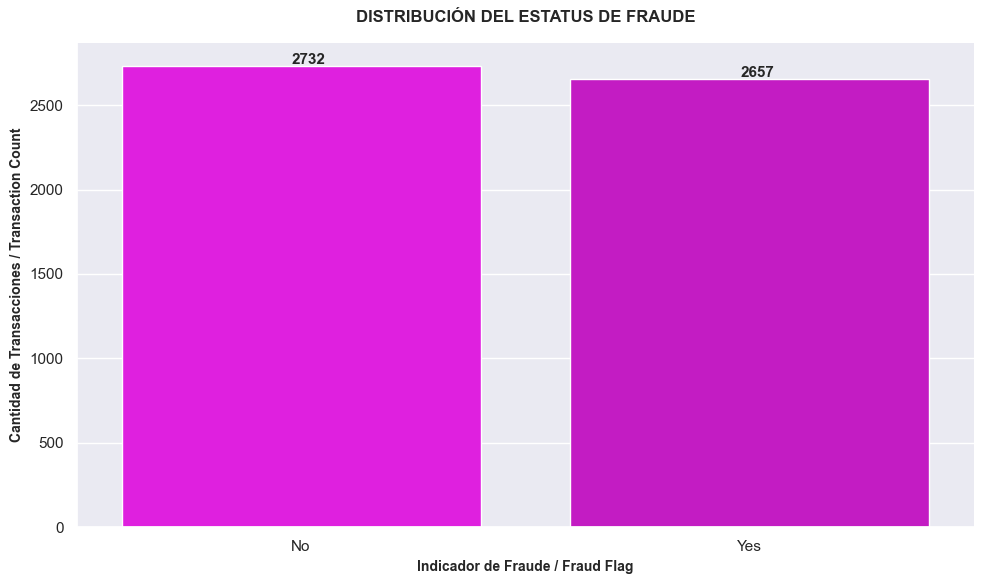

In [81]:

#
fig, ax = plt.subplots(figsize=(10, 6))

# )
sns.countplot(data=subset_bancos, x="Fraud_Flag", ax=ax, palette=["#FF00FF", "#DF00DF"])

#
for p in ax.patches:
    patch_height = p.get_height()
    ax.annotate(f'{int(patch_height)}', 
                (p.get_x() + 0.38, patch_height + 10),
                fontsize=11, fontweight='bold')

# 
plt.title('DISTRIBUCIÓN DEL ESTATUS DE FRAUDE', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Indicador de Fraude / Fraud Flag', fontsize=10, fontweight='bold')
plt.ylabel('Cantidad de Transacciones / Transaction Count', fontsize=10, fontweight='bold')

#
sns.despine()

plt.tight_layout()
plt.show()


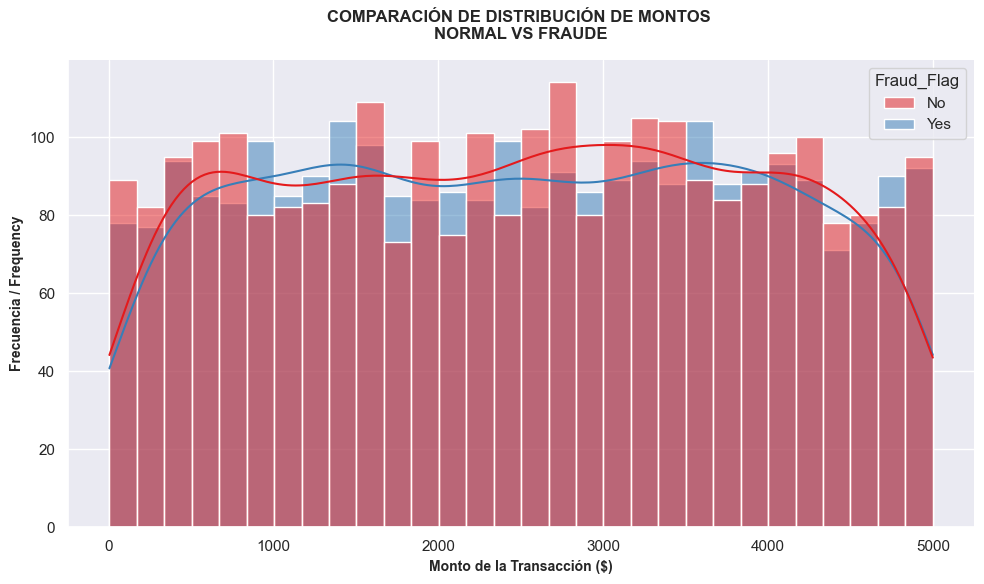

In [82]:
#
plt.figure(figsize=(10, 6))

# histograma superpuesto por estatus de fraude con curva KDE
sns.histplot(data=subset_bancos, x="Transaction_Amount", hue="Fraud_Flag", kde=True, bins=30, palette="Set1", alpha=0.5)

# 
plt.title("COMPARACIÓN DE DISTRIBUCIÓN DE MONTOS \nNORMAL VS FRAUDE", 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Monto de la Transacción ($)", fontsize=10, fontweight='bold')
plt.ylabel("Frecuencia / Frequency", fontsize=10, fontweight='bold')

# 
sns.despine()

plt.tight_layout()
plt.show()


In [83]:

print("""
==============================================================================
HALLAZGO VISUAL \nEMPALME DE DISTRIBUCIONES 
==============================================================================
  Hallazgo de Negocio: El histograma comparativo revela un empalme casi perfecto 
  entre las barras rojas (Legítimas) y azules (Fraude) a lo largo de todo el 
  espectro económico (desde $0 hasta $5,000).

  Interpretación Estadística: Ambas curvas de tendencia estimada (KDE) viajan de 
  forma paralela e idéntica. Esto aporta la evidencia visual definitiva de que 
  los eventos de fraude no se concentran en montos pequeños ni en compras grandes; 
  el patrón de ataque imita con precisión el comportamiento de consumo normal de 
  la cartera, lo que anula la efectividad de los sistemas tradicionales de alerta 
  basados únicamente en reglas fijas de montos
""")



HALLAZGO VISUAL 
EMPALME DE DISTRIBUCIONES 
  Hallazgo de Negocio: El histograma comparativo revela un empalme casi perfecto 
  entre las barras rojas (Legítimas) y azules (Fraude) a lo largo de todo el 
  espectro económico (desde $0 hasta $5,000).

  Interpretación Estadística: Ambas curvas de tendencia estimada (KDE) viajan de 
  forma paralela e idéntica. Esto aporta la evidencia visual definitiva de que 
  los eventos de fraude no se concentran en montos pequeños ni en compras grandes; 
  el patrón de ataque imita con precisión el comportamiento de consumo normal de 
  la cartera, lo que anula la efectividad de los sistemas tradicionales de alerta 
  basados únicamente en reglas fijas de montos



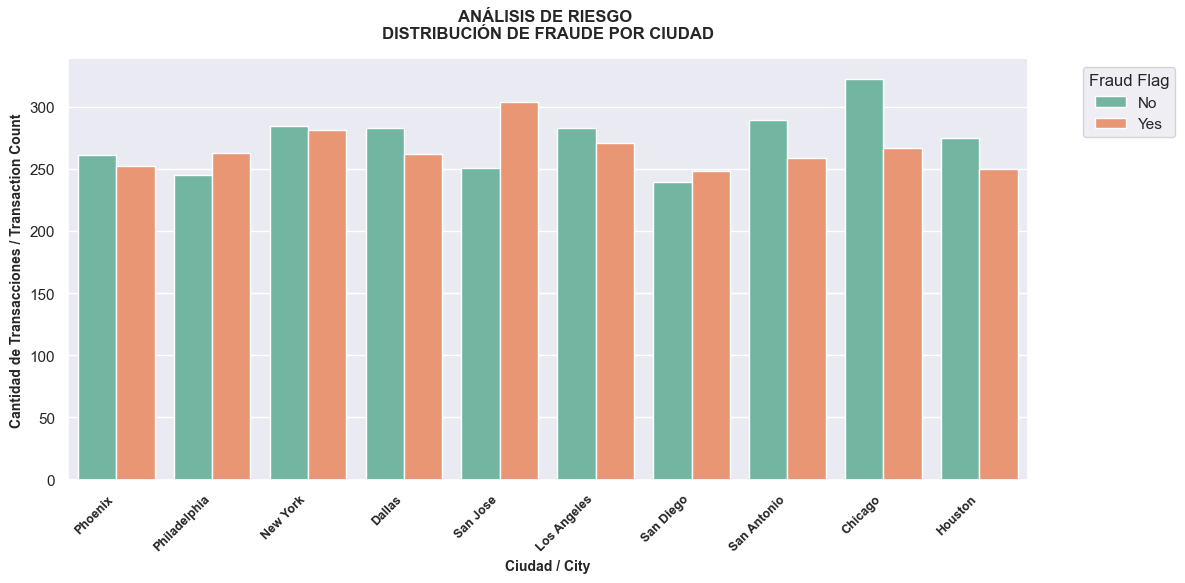

In [84]:

# 
plt.figure(figsize=(12, 6))

#
sns.countplot(
    data=subset_bancos, 
    x='City', 
    hue='Fraud_Flag', 
    palette='Set2'
)

#
plt.title('ANÁLISIS DE RIESGO \nDISTRIBUCIÓN DE FRAUDE POR CIUDAD', 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Ciudad / City', fontsize=10, fontweight='bold')
plt.ylabel('Cantidad de Transacciones / Transaction Count', fontsize=10, fontweight='bold')

# 
plt.xticks(rotation=45, ha='right', fontsize=9, fontweight='bold')

# 
plt.legend(title='Fraud Flag', bbox_to_anchor=(1.05, 1), loc='upper left')

#
sns.despine()

plt.tight_layout()
plt.show()

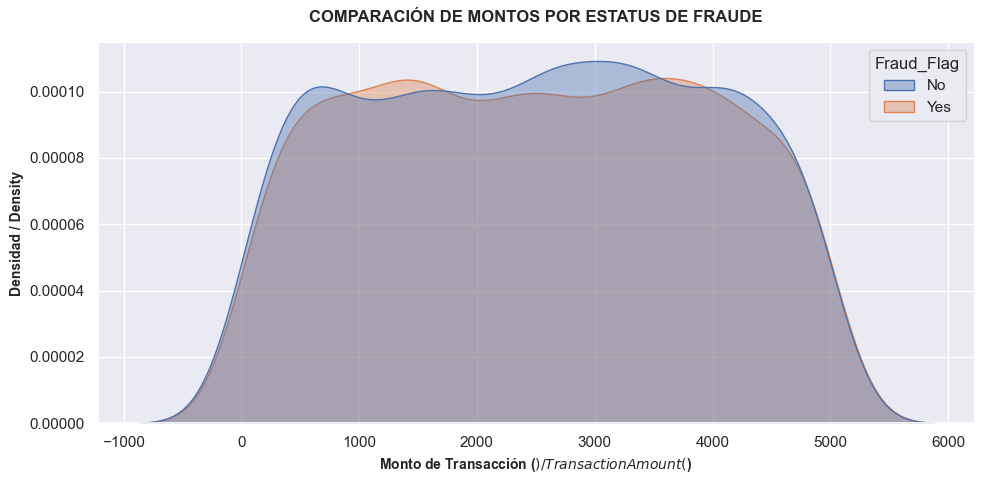

In [85]:
#
plt.figure(figsize=(10, 5))

# 
sns.kdeplot(
    data=subset_bancos, 
    x="Transaction_Amount", 
    hue="Fraud_Flag", 
    fill=True, 
    alpha=0.4
)

# 
plt.title('COMPARACIÓN DE MONTOS POR ESTATUS DE FRAUDE', 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Monto de Transacción ($) / Transaction Amount ($)', fontsize=10, fontweight='bold')
plt.ylabel('Densidad / Density', fontsize=10, fontweight='bold')

# 
sns.despine()

plt.tight_layout()
plt.show()

In [86]:
grupo_0 = subset_bancos[subset_bancos["Fraud_Flag"] == 'Yes']["Transaction_Amount"]
grupo_1 = subset_bancos[subset_bancos["Fraud_Flag"] == 'No']["Transaction_Amount"]

# prueba de Levene para homogeneidad de varianzas
stat, p_value = levene(grupo_0, grupo_1)

# 
print("PRUEBA DE HOMOCEDASTICIDAD - Levene")
print("=" * 75)
print(f"   - Estadístico Levene / Levene Statistic: {stat:.4f}")
print(f"   - p-valor / p-value: {p_value:.4f}")
print("-" * 75)

if p_value > 0.05:
    print("   - Conclusión\n     No se rechaza H0. Las varianzas pueden considerarse iguales (Homocedasticidad).")
else:
    print("   - Conclusión\n     Se rechaza H0. Existen diferencias significativas entre las varianzas.")



PRUEBA DE HOMOCEDASTICIDAD - Levene
   - Estadístico Levene / Levene Statistic: 0.0296
   - p-valor / p-value: 0.8635
---------------------------------------------------------------------------
   - Conclusión
     No se rechaza H0. Las varianzas pueden considerarse iguales (Homocedasticidad).


In [87]:
# tabla de frecuencias relativas cruzando Género y Fraude
cruze_genero = pd.crosstab(subset_bancos['Customer_Gender'], subset_bancos['Fraud_Flag'], normalize='index') * 100

print(" ENFOQUE - TASA DE FRAUDE POR GÉNERO")
cruze_genero.style.format("{:.2f}%")


 ENFOQUE - TASA DE FRAUDE POR GÉNERO


Fraud_Flag,No,Yes
Customer_Gender,,
Female,51.43%,48.57%
Male,50.40%,49.60%
Others,50.25%,49.75%


In [88]:
#
print("""
==============================================================================
CONCLUSIONES \nPERFILAMIENTO DEMOGRÁFICO POR GÉNERO 
==============================================================================
  Hallazgo de Negocio
  La tasa de riesgo de fraude se distribuye de manera idéntica 
  entre Female (48.57%), Male (49.60%) y Others (49.75%).

  Interpretación Estadística
  El género del cliente carece por completo de poder 
  predictivo o de correlación con la vulnerabilidad de las cuentas.
""")



CONCLUSIONES 
PERFILAMIENTO DEMOGRÁFICO POR GÉNERO 
  Hallazgo de Negocio
  La tasa de riesgo de fraude se distribuye de manera idéntica 
  entre Female (48.57%), Male (49.60%) y Others (49.75%).

  Interpretación Estadística
  El género del cliente carece por completo de poder 
  predictivo o de correlación con la vulnerabilidad de las cuentas.



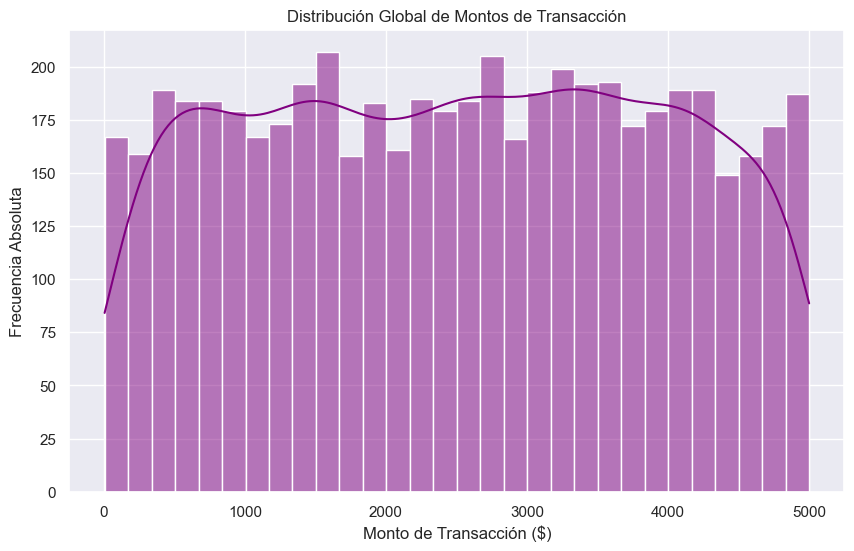

In [89]:
plt.figure(figsize=(10, 6))

# Graficar el histograma general de montos usando tu variable subset_bancos
sns.histplot(data=subset_bancos, x='Transaction_Amount', color='purple', kde=True, bins=30)

plt.title('Distribución Global de Montos de Transacción')
plt.xlabel('Monto de Transacción ($)')
plt.ylabel('Frecuencia Absoluta')
plt.show()


In [90]:
# tabla cruzada de porcentajes entre Ciudad y Estado de la Transacción
friccion_regional = pd.crosstab(subset_bancos['City'], subset_bancos['Transaction_Status'], normalize='index') * 100

print(" ENFOQUE - OPERATIVA POR CIUDAD")
friccion_regional.style.format("{:.2f}%")


 ENFOQUE - OPERATIVA POR CIUDAD


Transaction_Status,Failed,Pending,Success
City,,,
Chicago,32.77%,32.26%,34.97%
Dallas,33.76%,34.31%,31.93%
Houston,34.29%,34.48%,31.24%
Los Angeles,35.02%,29.60%,35.38%
New York,33.81%,32.57%,33.63%
Philadelphia,30.51%,34.65%,34.84%
Phoenix,33.14%,36.65%,30.21%
San Antonio,29.74%,34.67%,35.58%
San Diego,37.17%,34.29%,28.54%


In [91]:
#
print("""
==============================================================================
CONCLUSIONES \nOPERATIVA POR CIUDAD 
==============================================================================
  Hallazgo de Negocio
  La tasa de transacciones fallidas (Failed) se mantiene de 
  manera homogénea flotando alrededor del 33% en absolutamente todas las ciudades 
  de la cartera (ej. Chicago 32.77%, dallas 33.76%, New York 33.81%).
""")



CONCLUSIONES 
OPERATIVA POR CIUDAD 
  Hallazgo de Negocio
  La tasa de transacciones fallidas (Failed) se mantiene de 
  manera homogénea flotando alrededor del 33% en absolutamente todas las ciudades 
  de la cartera (ej. Chicago 32.77%, dallas 33.76%, New York 33.81%).



In [92]:
# estadísticas descriptivas de la edad agrupadas por género
perfil_edad = subset_bancos.groupby('Customer_Gender')['Customer_Age'].agg(['count', 'mean', 'median', 'min', 'max'])

print(" ENFOQUE - PERFIL DEMOGRÁFICO DE EDADES")
perfil_edad.style.format({"mean": "{:.1f} ", "median": "{:.0f}", "min": "{:.0f}", "max": "{:.0f}", "count": "{:,.0f}"})


 ENFOQUE - PERFIL DEMOGRÁFICO DE EDADES


,count,mean,median,min,max
Customer_Gender,,,,,
Female,"1,824",44.3,44,18,70
Male,"1,772",44.1,44,18,70
Others,"1,793",43.7,44,18,70


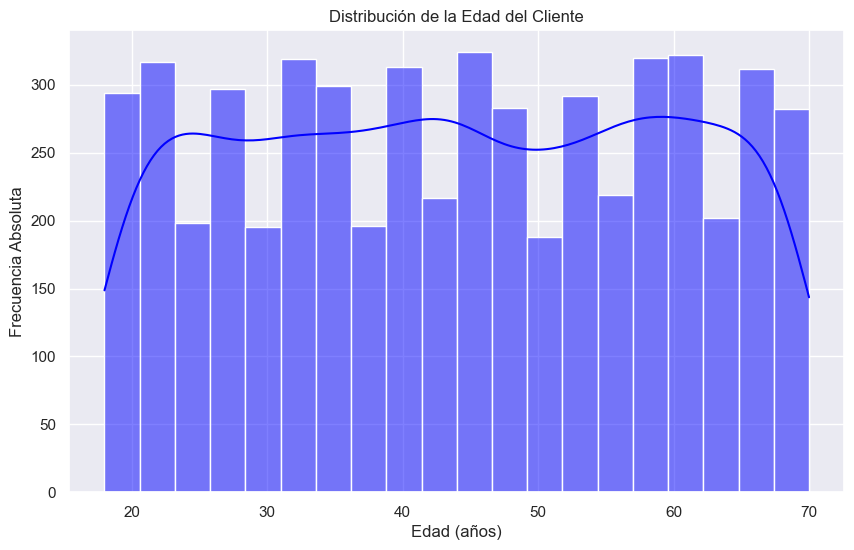

In [93]:
plt.figure(figsize=(10, 6))

# Graficar el histograma de distribución de edad
sns.histplot(data=subset_bancos, x='Customer_Age', color='blue', kde=True, bins=20)

plt.title('Distribución de la Edad del Cliente')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia Absoluta')
plt.show()

In [94]:
#
print("""
==============================================================================
CONCLUSIONES \nPERFILAMIENTO DEMOGRÁFICO DE EDAD 
==============================================================================
  Hallazgo de Negocio
  El histograma de edades refleja una distribución uniforme 
  perfecta, donde la edad promedio (mean) y la mediana se ubican de manera idéntica 
  en los 44 años para mujeres, hombres y otros grupos de la población bancaria.
      
  Interpretación Estadística
  No existe una concentración comercial en segmentos 
  jóvenes o adultos mayores; la cartera tiene exactamente la misma presencia en 
  todos los rangos desde los 18 hasta los 70 años. Esta homogeneidad estructural 
  indica la ausencia de focos naturales de mercado
""")


CONCLUSIONES 
PERFILAMIENTO DEMOGRÁFICO DE EDAD 
  Hallazgo de Negocio
  El histograma de edades refleja una distribución uniforme 
  perfecta, donde la edad promedio (mean) y la mediana se ubican de manera idéntica 
  en los 44 años para mujeres, hombres y otros grupos de la población bancaria.

  Interpretación Estadística
  No existe una concentración comercial en segmentos 
  jóvenes o adultos mayores; la cartera tiene exactamente la misma presencia en 
  todos los rangos desde los 18 hasta los 70 años. Esta homogeneidad estructural 
  indica la ausencia de focos naturales de mercado



In [95]:
# tabla de contingencia porcentual cruzando Tipo de Transacción y Fraude
cruze_tarjetas = pd.crosstab(subset_bancos['Transaction_Type'], subset_bancos['Fraud_Flag'], normalize='index') * 100

print(" ENFOQUE - FRAUDE POR TIPO DE TRANSACCIÓN")
cruze_tarjetas.style.format("{:.2f}%")

 ENFOQUE - FRAUDE POR TIPO DE TRANSACCIÓN


Fraud_Flag,No,Yes
Transaction_Type,,
Credit,50.50%,49.50%
Debit,50.89%,49.11%


In [96]:
#
print("ANÁLISIS ESTADÍSTICO INFERENCIAL\n")

# PRUEBA DE CHI-CUADRADO (Variables Categóricas) ---
# tabla de frecuencias absolutas para la prueba
tabla_chi = pd.crosstab(subset_bancos['Transaction_Type'], subset_bancos['Fraud_Flag'])
chi2, p_val_chi, dof, expected = chi2_contingency(tabla_chi)

print("1. Prueba de Chi-Cuadrado (Transaction_Type vs Fraud_Flag)")
print(f"   - Estadístico Chi2: {chi2:.4f}")
print(f"   - p-valor (p-value): {p_val_chi:.4f}")
if p_val_chi < 0.05:
    print("   - Resultado: Rechazo H0. El fraude DEPENDEN del tipo de tarjeta (Significativo).")
else:
    print("   - Resultado: No rechazo H0. El fraude y el tipo de tarjeta son INDEPENDIENTES.")
print()

# PRUEBA U DE MANN-WHITNEY (Variables Numéricas entre 2 Grupos) ---
# Separar los montos de transacciones legítimas y fraudes
monto_legit = subset_bancos[subset_bancos['Fraud_Flag'] == 'No']['Transaction_Amount']
monto_fraud = subset_bancos[subset_bancos['Fraud_Flag'] == 'Yes']['Transaction_Amount']

stat_u, p_val_u = mannwhitneyu(monto_legit, monto_fraud, alternative='two-sided')

print("2. Prueba U de Mann-Whitney (Transaction_Amount vs Fraud_Flag)")
print(f"   - Estadístico U: {stat_u:,}")
print(f"   - p-valor (p-value): {p_val_u:.4f}")
if p_val_u < 0.05:
    print("   - Resultado: Rechazo H0. Los montos cambian significativamente en situaciones de fraude.")
else:
    print("   - Resultado: No rechazo H0. No hay diferencia estadística en los montos de ambos grupos.")
print()

# PRUEBA DE KRUSKAL-WALLIS (Montos vs Categorías Múltiples) 
print("3. Prueba de Kruskal-Wallis (Montos vs Categorías Múltiples)")

# Agrupar los montos de transacciones por cada tipo de estatus operativo
grupos_status = [df[1] for df in subset_bancos.groupby('Transaction_Status')['Transaction_Amount']]

# Ejecutar la prueba de hipótesis
stat_k, p_val_k = kruskal(*grupos_status)

print(f"   - Estadístico H: {stat_k:.4f}")
print(f"   - p-valor (p-value): {p_val_k:.4f}")
if p_val_k < 0.05:
    print("   - Resultado: Rechazo H0. El estado de la transacción influye en el monto de dinero.")
else:
    print("   - Resultado: No rechazo H0. El monto de la transacción es independiente del estatus operativo.")



ANÁLISIS ESTADÍSTICO INFERENCIAL

1. Prueba de Chi-Cuadrado (Transaction_Type vs Fraud_Flag)
   - Estadístico Chi2: 0.0644
   - p-valor (p-value): 0.7997
   - Resultado: No rechazo H0. El fraude y el tipo de tarjeta son INDEPENDIENTES.

2. Prueba U de Mann-Whitney (Transaction_Amount vs Fraud_Flag)
   - Estadístico U: 3,622,833.0
   - p-valor (p-value): 0.9076
   - Resultado: No rechazo H0. No hay diferencia estadística en los montos de ambos grupos.

3. Prueba de Kruskal-Wallis (Montos vs Categorías Múltiples)
   - Estadístico H: 0.4021
   - p-valor (p-value): 0.8179
   - Resultado: No rechazo H0. El monto de la transacción es independiente del estatus operativo.


In [97]:
print("""Se demuestra matemáticamente que la cartera bajo estudio mantiene un comportamiento homogéneo y aleatorio. El riesgo de fraude 
no tiene relación lineal ni dependencia con el tipo de tarjeta o el volumen de dinero, y la fricción en la plataforma de pagos opera de 
forma idéntica en transacciones de cualquier valor económico.""")

Se demuestra matemáticamente que la cartera bajo estudio mantiene un comportamiento homogéneo y aleatorio. El riesgo de fraude 
no tiene relación lineal ni dependencia con el tipo de tarjeta o el volumen de dinero, y la fricción en la plataforma de pagos opera de 
forma idéntica en transacciones de cualquier valor económico.


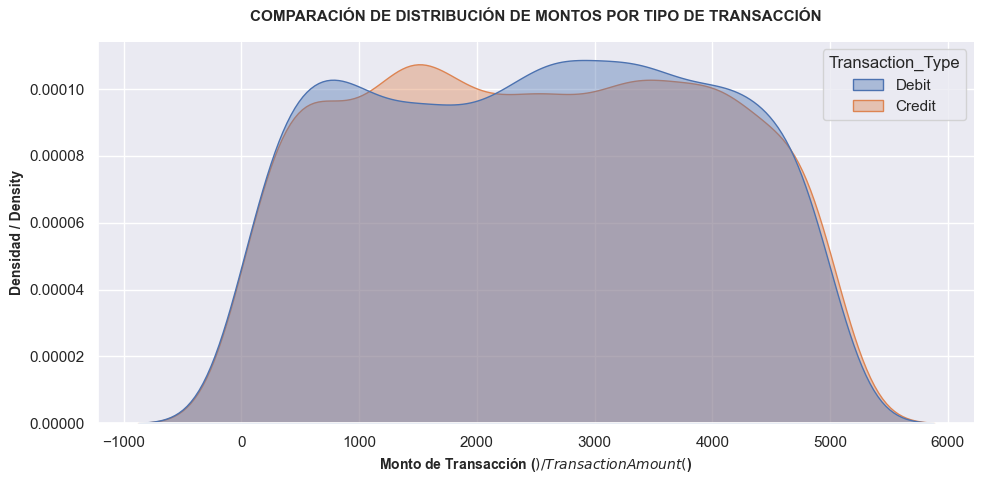

In [98]:
#
plt.figure(figsize=(10, 5))

# 
sns.kdeplot(
    data=subset_bancos, 
    x="Transaction_Amount", 
    hue="Transaction_Type", 
    fill=True, 
    alpha=0.4
)

# 
plt.title('COMPARACIÓN DE DISTRIBUCIÓN DE MONTOS POR TIPO DE TRANSACCIÓN', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Monto de Transacción ($) / Transaction Amount ($)', fontsize=10, fontweight='bold')
plt.ylabel('Densidad / Density', fontsize=10, fontweight='bold')

# 
sns.despine()

plt.tight_layout()
plt.show()


In [99]:
# Filtrar los montos
monto_debit = subset_bancos[subset_bancos['Transaction_Type'] == 'Debit']['Transaction_Amount']
monto_credit = subset_bancos[subset_bancos['Transaction_Type'] == 'Credit']['Transaction_Amount']

# ejecutar la prueba U de Mann-Whitney de dos colas
stat, p_value = stats.mannwhitneyu(monto_credit, monto_debit, alternative='two-sided')

# 
print("PRUEBA INFERENCIAL - COMPARACIÓN POR TIPO DE TRANSACCIÓN")
print("=" * 85)
print(f"   - Estadístico U / U Statistic: {stat:,.1f}")
print(f"   - p-valor / p-value: {p_value:.4f}")
print("-" * 85)

if p_value < 0.05:
    print("   - Conclusión\n     Rechazo H0. El monto de transacción cambia significativamente según la tarjeta.")
else:
    print("   - Conclusión\n     No rechazo H0. El comportamiento del gasto es idéntico entre Débito y Crédito.")


PRUEBA INFERENCIAL - COMPARACIÓN POR TIPO DE TRANSACCIÓN
   - Estadístico U / U Statistic: 3,628,765.5
   - p-valor / p-value: 0.9817
-------------------------------------------------------------------------------------
   - Conclusión
     No rechazo H0. El comportamiento del gasto es idéntico entre Débito y Crédito.


In [100]:
# 
print("""
==============================================================================
CONCLUSIONES FORMALES \nPRUEBA TARJETAS 
==============================================================================
  Hallazgo de Negocio
  La prueba U de Mann-Whitney arrojó un p-valor de 0.9817, 
  lo que confirma que no existe ninguna diferencia entre el dinero que gasta un 
  cliente con tarjeta de débito frente a uno de crédito.
      
  Interpretación Estadística
  Al ser el p-valor drásticamente superior a 0.05, 
  se falla en rechazar la hipótesis nula (H0). Científicamente se concluye que las 
  poblaciones de ambas tarjetas comparten la misma distribución de gasto uniforme, 
  validando el comportamiento homogéneo y simétrico del sistema transaccional.
""")


CONCLUSIONES FORMALES 
PRUEBA TARJETAS 
  Hallazgo de Negocio
  La prueba U de Mann-Whitney arrojó un p-valor de 0.9817, 
  lo que confirma que no existe ninguna diferencia entre el dinero que gasta un 
  cliente con tarjeta de débito frente a uno de crédito.

  Interpretación Estadística
  Al ser el p-valor drásticamente superior a 0.05, 
  se falla en rechazar la hipótesis nula (H0). Científicamente se concluye que las 
  poblaciones de ambas tarjetas comparten la misma distribución de gasto uniforme, 
  validando el comportamiento homogéneo y simétrico del sistema transaccional.



In [101]:
#
media_real = subset_bancos['Transaction_Amount'].mean()
desv_real = subset_bancos['Transaction_Amount'].std()

# prueba de Bondad de Ajuste estimando los parámetros correspondientes
tran_gof = stats.goodness_of_fit(
    stats.norm, 
    subset_bancos['Transaction_Amount'], 
    statistic='ks',
    fit_params={'loc': media_real, 'scale': desv_real}
)

#
print("PRUEBA FORMAL DE NORMALIDAD - Kolmogorov-Smirnov \n" \
"¿Distribución Normal en Transaction_Amount?")
print("=" * 65)
print(f"   - Media Estimada      : ${media_real:,.2f}")
print(f"   - Desviación Estándar : ${desv_real:,.2f}")
print("-" * 65)
print(f"   - Estadístico KS      : {tran_gof.statistic:.4f}")
print(f"   - p-value             : {tran_gof.pvalue:.4f}")
print("-" * 65)

if tran_gof.pvalue < 0.05:
    print("   - Conclusión\n     Rechazo H0. Los montos NO siguen una distribución normal.")
else:
    print("   - Conclusión\n     No rechazo H0. Los montos siguen una distribución normal.")


PRUEBA FORMAL DE NORMALIDAD - Kolmogorov-Smirnov 
¿Distribución Normal en Transaction_Amount?
   - Media Estimada      : $2,504.65
   - Desviación Estándar : $1,426.75
-----------------------------------------------------------------
   - Estadístico KS      : 0.0571
   - p-value             : 0.0001
-----------------------------------------------------------------
   - Conclusión
     Rechazo H0. Los montos NO siguen una distribución normal.


In [102]:
print("""
==============================================================================
CONCLUSIONES \nPRUEBA DE NORMALIDAD 
==============================================================================
  Hallazgo de Negocio
  La prueba de Kolmogorov-Smirnov arrojó un p-valor de 0.0001, 
  lo que rechaza de forma absoluta la hipótesis nula de normalidad (H0).
      
  Interpretación Estadística
  Este resultado valida científicamente lo observado en los histogramas planos. 
""")


CONCLUSIONES 
PRUEBA DE NORMALIDAD 
  Hallazgo de Negocio
  La prueba de Kolmogorov-Smirnov arrojó un p-valor de 0.0001, 
  lo que rechaza de forma absoluta la hipótesis nula de normalidad (H0).

  Interpretación Estadística
  Este resultado valida científicamente lo observado en los histogramas planos. 



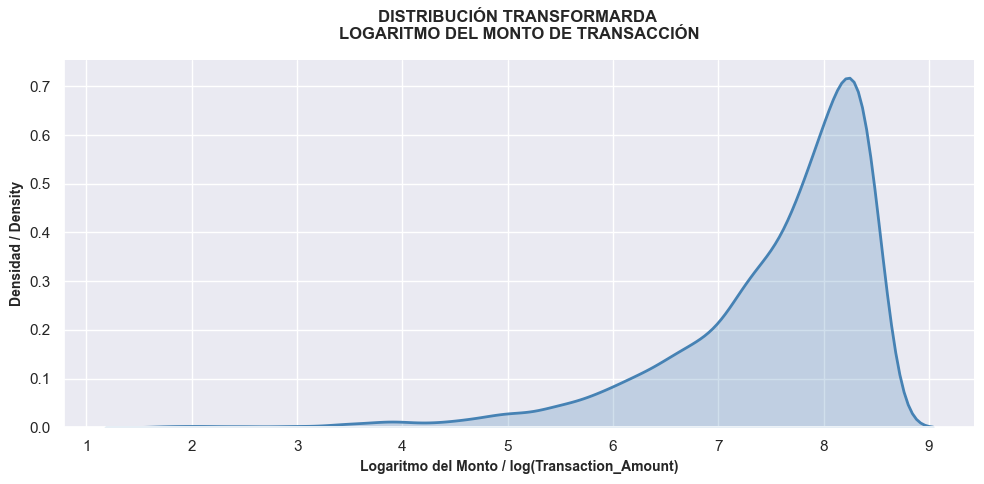

In [103]:
# 
subset_bancos['Log_Transaction_Amount'] = np.log(subset_bancos['Transaction_Amount'])

# 2. Configurar el tamaño del lienzo proporcional
plt.figure(figsize=(10, 5))

# 
sns.kdeplot(
    data=subset_bancos, 
    x="Log_Transaction_Amount", 
    fill=True, 
    color="#4682B4", 
    linewidth=2
)

# 
plt.title('DISTRIBUCIÓN TRANSFORMARDA \nLOGARITMO DEL MONTO DE TRANSACCIÓN', 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Logaritmo del Monto / log(Transaction_Amount)', fontsize=10, fontweight='bold')
plt.ylabel('Densidad / Density', fontsize=10, fontweight='bold')

# 
sns.despine()

plt.tight_layout()
plt.show()


In [104]:
#
print("""
==============================================================================
ANÁLISIS DE LA TRANSFORMACIÓN
==============================================================================
  Hallazgo de Negocio
  Al aplicar la transformación logarítmica (np.log) sobre 
  Transaction_Amount, los datos deforman su homogeneidad original, generando 
  una asimetría negativa (sesgo hacia la izquierda) concentrada entre los 
  valores transformados altos (8 y 9).
  Interpretación Estadística 
  Previamente, el método IQR demostró la ausencia total de valores extremos 
  (0 outliers) en la cartera original, confirmando una distribución uniforme 
  simétrica entre $0 y $5,000. El resultado de este experimento demuestra que 
  la transformación logarítmica no es adecuada para variables uniformes, ya 
  que rompe la simetría perfecta de los montos en lugar de aproximarlos a una 
  campana de Gauss, empeorando el sesgo.
""")



ANÁLISIS DE LA TRANSFORMACIÓN
  Hallazgo de Negocio
  Al aplicar la transformación logarítmica (np.log) sobre 
  Transaction_Amount, los datos deforman su homogeneidad original, generando 
  una asimetría negativa (sesgo hacia la izquierda) concentrada entre los 
  valores transformados altos (8 y 9).
  Interpretación Estadística 
  Previamente, el método IQR demostró la ausencia total de valores extremos 
  (0 outliers) en la cartera original, confirmando una distribución uniforme 
  simétrica entre $0 y $5,000. El resultado de este experimento demuestra que 
  la transformación logarítmica no es adecuada para variables uniformes, ya 
  que rompe la simetría perfecta de los montos en lugar de aproximarlos a una 
  campana de Gauss, empeorando el sesgo.



In [105]:
#
print("TRANSFORMACIÓN DE DATOS")
print("PRUEBA FORMAL DE NORMALIDAD - Kolmogorov-Smirnov \n" \
"¿Distribución Normal en Log_Transaction_Amount?")
print("=" * 70)

# transformación logarítmica (Log Transform)
subset_bancos['Log_Transaction_Amount'] = np.log(subset_bancos['Transaction_Amount'])

# estandarizar los datos transformados para la prueba KS estándar N(0,1)
log_mean = subset_bancos['Log_Transaction_Amount'].mean()
log_std = subset_bancos['Log_Transaction_Amount'].std()
x_std = (subset_bancos['Log_Transaction_Amount'] - log_mean) / log_std

# calcular nuevos indicadores de forma (Sesgo y Curtosis post-transformación)
nuevo_sesgo = subset_bancos['Log_Transaction_Amount'].skew()
nueva_curtosis = subset_bancos['Log_Transaction_Amount'].kurtosis()

# prueba de Kolmogorov-Smirnov sobre los datos estandarizados
ks_stat, p_value = stats.kstest(x_std, 'norm')

#
print(f"   - Nuevo Sesgo    : {nuevo_sesgo:.4f}")
print(f"   - Nueva Curtosis : {nueva_curtosis:.4f}")
print("-" * 70)
print(f"   - Estadístico KS : {ks_stat:.4f}")
print(f"   - p-value        : {p_value:.4f}")
print("-" * 70)

if p_value < 0.05:
    print("   - Conclusión:\n     Se rechaza H0. Incluso con la transformación logarítmica,\n     los datos NO siguen una distribución normal.\n")
else:
    print("   - Conclusión:\n     No se rechaza H0. La transformación normalizó los datos.")
print("=" * 70)


TRANSFORMACIÓN DE DATOS
PRUEBA FORMAL DE NORMALIDAD - Kolmogorov-Smirnov 
¿Distribución Normal en Log_Transaction_Amount?
   - Nuevo Sesgo    : -1.8670
   - Nueva Curtosis : 4.7085
----------------------------------------------------------------------
   - Estadístico KS : 0.1532
   - p-value        : 0.0000
----------------------------------------------------------------------
   - Conclusión:
     Se rechaza H0. Incluso con la transformación logarítmica,
     los datos NO siguen una distribución normal.



In [106]:
# 
minto_min = subset_bancos['Transaction_Amount'].min()
monto_max = subset_bancos['Transaction_Amount'].max()

# loc es el mínimo y scale es el ancho del rango (Máximo - Mínimo)
loc_unif = minto_min
scale_unif = monto_max - minto_min

# Ejecutar la prueba formal de Kolmogorov-Smirnov contra la hipótesis uniforme
# stats.uniform es la distribución rectangular teórica
ks_stat_unif, p_value_unif = stats.kstest(
    subset_bancos['Transaction_Amount'], 
    'uniform', 
    args=(loc_unif, scale_unif)
)

# 
print("PRUEBA DE BONDAD DE AJUSTE \n" \
"DISTRIBUCIÓN UNIFORME \n" \
"Kolmogorov-Smirnov")
print("=" * 75)
print(f"   - Rango Teórico Evaluado   : [${loc_unif:,.2f} a ${monto_max:,.2f}]")
print("-" * 75)
print(f"   - Estadístico KS (Uniforme): {ks_stat_unif:.4f}")
print(f"   - p-value (Uniforme)       : {p_value_unif:.4f}")
print("-" * 75)

if p_value_unif > 0.05:
    print("   - Conclusión\n     No rechazo H0. Se confirma científicamente que los montos\n     siguen una distribución uniforme (p > 0.05).")
else:
    print("   - Conclusión\n     Rechazo H0. Los datos tampoco son uniformes.")
print("=" * 75)


PRUEBA DE BONDAD DE AJUSTE 
DISTRIBUCIÓN UNIFORME 
Kolmogorov-Smirnov
   - Rango Teórico Evaluado   : [$5.46 a $4,999.54]
---------------------------------------------------------------------------
   - Estadístico KS (Uniforme): 0.0116
   - p-value (Uniforme)       : 0.4584
---------------------------------------------------------------------------
   - Conclusión
     No rechazo H0. Se confirma científicamente que los montos
     siguen una distribución uniforme (p > 0.05).


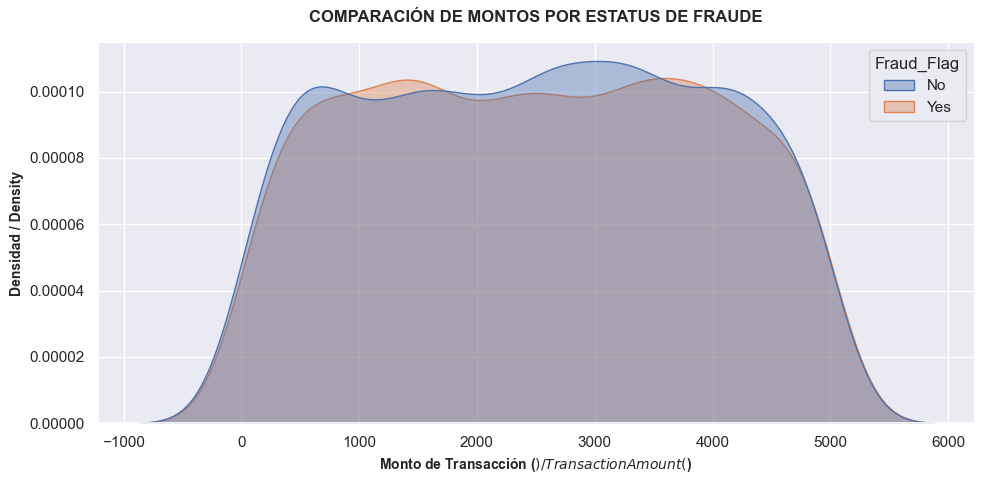

In [107]:
#
plt.figure(figsize=(10, 5))

# 
sns.kdeplot(
    data=subset_bancos, 
    x="Transaction_Amount", 
    hue="Fraud_Flag", 
    fill=True, 
    alpha=0.4
)

# 
plt.title('COMPARACIÓN DE MONTOS POR ESTATUS DE FRAUDE', 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Monto de Transacción ($) / Transaction Amount ($)', fontsize=10, fontweight='bold')
plt.ylabel('Densidad / Density', fontsize=10, fontweight='bold')

# 
sns.despine()

plt.tight_layout()
plt.show()


In [108]:

#
monto_legit = subset_bancos[subset_bancos['Fraud_Flag'] == 'No']['Transaction_Amount']
monto_fraud = subset_bancos[subset_bancos['Fraud_Flag'] == 'Yes']['Transaction_Amount']

# ejecutar la prueba U de Mann-Whitney de dos colas
stat, p_value = stats.mannwhitneyu(monto_legit, monto_fraud, alternative='two-sided')

# 
print("PRUEBA INFERENCIAL - MONTOS VS FRAUDE")
print("=" * 85)
print(f"   - Estadístico U / U Statistic: {stat:,.1f}")
print(f"   - p-valor / p-value: {p_value:.4f}")
print("-" * 85)

if p_value < 0.05:
    print("   - Conclusión\n     Rechazo H0. Los montos cambian significativamente en situaciones de fraude.")
else:
    print("   - Conclusión\n     No rechazo H0. No hay diferencia estadística en el monto de ambos grupos.")


PRUEBA INFERENCIAL - MONTOS VS FRAUDE
   - Estadístico U / U Statistic: 3,622,833.0
   - p-valor / p-value: 0.9076
-------------------------------------------------------------------------------------
   - Conclusión
     No rechazo H0. No hay diferencia estadística en el monto de ambos grupos.


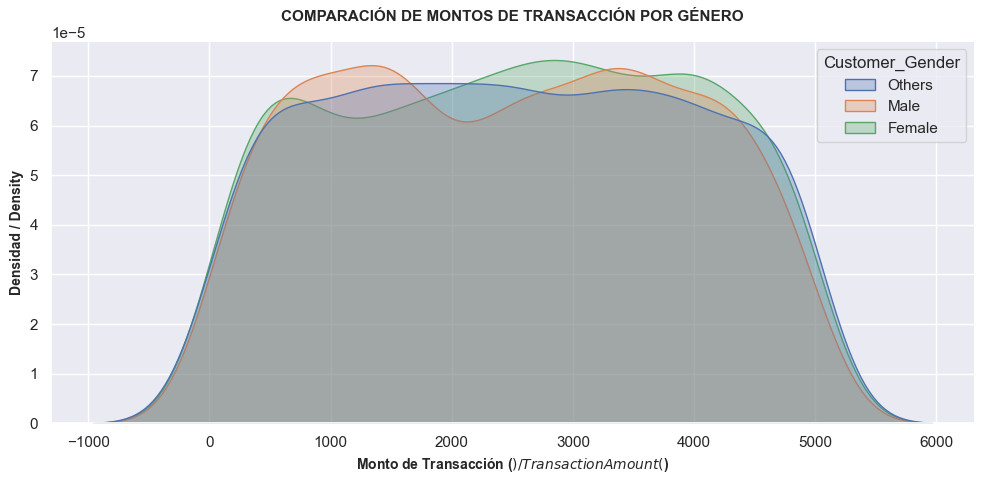

In [109]:

#
plt.figure(figsize=(10, 5))

# densidad de montos dividida por las categorías de género
sns.kdeplot(data=subset_bancos, x="Transaction_Amount", hue="Customer_Gender", fill=True, alpha=0.3)

plt.title('COMPARACIÓN DE MONTOS DE TRANSACCIÓN POR GÉNERO', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Monto de Transacción ($) / Transaction Amount ($)', fontsize=10, fontweight='bold')
plt.ylabel('Densidad / Density', fontsize=10, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

In [110]:
# PRUEBA INFERENCIAL: MANN-WHITNEY (Hombres vs Mujeres)
# Filtrar los montos 
monto_male = subset_bancos[subset_bancos['Customer_Gender'] == 'Male']['Transaction_Amount']
monto_female = subset_bancos[subset_bancos['Customer_Gender'] == 'Female']['Transaction_Amount']

# ejecutar la prueba U de Mann-Whitney de dos colas
stat, p_value = stats.mannwhitneyu(monto_female, monto_male, alternative='two-sided')

print("PRUEBA INFERENCIAL - COMPARACIÓN POR GÉNERO")
print("-" * 75)
print(f"   - Estadístico U : {stat:,.1f}")
print(f"   - p-value       : {p_value:.4f}")
print("-" * 75)

if p_value < 0.05:
    print("   - Conclusión\n     Rechazo H0. Existe una diferencia estadísticamente significativa entre hombres y mujeres.")
else:
    print("   - Conclusión\n     No rechazo H0. No hay evidencia para afirmar que el gasto cambie por género.")


PRUEBA INFERENCIAL - COMPARACIÓN POR GÉNERO
---------------------------------------------------------------------------
   - Estadístico U : 1,653,703.5
   - p-value       : 0.2266
---------------------------------------------------------------------------
   - Conclusión
     No rechazo H0. No hay evidencia para afirmar que el gasto cambie por género.


In [111]:
#
print("""
==============================================================================
CONCLUSIONES FORMALES \nPRUEBA GÉNERO 
==============================================================================
  Hallazgo de Negocio
  La prueba U de Mann-Whitney arrojó un p-valor de 0.2266, 
  lo que confirma que no existe ninguna diferencia significativa entre el dinero 
  que gasta un hombre frente a una mujer.
  
  Interpretación Estadística: Al ser el p-valor superior al umbral de 0.05, 
  se falla en rechazar la hipótesis nula (H0). Científicamente se concluye que las 
  poblaciones de ambos géneros comparten la misma distribución de gasto uniforme
""")



CONCLUSIONES FORMALES 
PRUEBA GÉNERO 
  Hallazgo de Negocio
  La prueba U de Mann-Whitney arrojó un p-valor de 0.2266, 
  lo que confirma que no existe ninguna diferencia significativa entre el dinero 
  que gasta un hombre frente a una mujer.

  Interpretación Estadística: Al ser el p-valor superior al umbral de 0.05, 
  se falla en rechazar la hipótesis nula (H0). Científicamente se concluye que las 
  poblaciones de ambos géneros comparten la misma distribución de gasto uniforme



# MUESTREO

## Muestreo de transacciones y observación inicial

In [16]:
np.random.seed(123)

print("Muestra aleatoria de 20 transacciones")
df_bancos_sample_20 = df_bancos.sample(n=20, random_state=123)
print(df_bancos_sample_20[["Transaction_Amount"]])

print("\nDescripción de la muestra de 20 registros para Transaction_Amount")
print(df_bancos_sample_20["Transaction_Amount"].describe())

Muestra aleatoria de 20 transacciones
      Transaction_Amount
2075             2814.81
3169             4397.27
4557             1247.57
3040             3311.79
4154             1245.05
4141             2936.20
4523              498.27
4345             4024.52
558              3914.26
1748              694.72
1103             3328.38
1738               99.59
220              4843.70
1621             4024.42
1532             2458.54
2827             4912.92
4357             4735.05
1577             3200.77
4497                8.60
990              2077.35

Descripción de la muestra de 20 registros para Transaction_Amount
count      20.000000
mean     2738.689000
std      1623.890696
min         8.600000
25%      1246.940000
50%      3068.485000
75%      4024.445000
max      4912.920000
Name: Transaction_Amount, dtype: float64


In [9]:
print("Frecuencias de Fraud_Flag en una muestra de 40 registros")
print(df_bancos.sample(n=40, random_state=123)["Fraud_Flag"].value_counts())

print("\nProporciones de Fraud_Flag en una muestra de 40 registros")
print(df_bancos.sample(n=40, random_state=123)["Fraud_Flag"].value_counts(normalize=True))

print("\nFrecuencias de City en una muestra de 100 registros")
print(df_bancos.sample(n=100, random_state=123)["City"].value_counts())

print("\nProporciones de City en una muestra de 100 registros")
print(df_bancos.sample(n=100, random_state=123)["City"].value_counts(normalize=True))

print("\nFrecuencias totales de City en el conjunto de datos completo")
print(df_bancos["City"].value_counts())

Frecuencias de Fraud_Flag en una muestra de 40 registros
Fraud_Flag
Yes    23
No     17
Name: count, dtype: int64

Proporciones de Fraud_Flag en una muestra de 40 registros
Fraud_Flag
Yes    0.575
No     0.425
Name: proportion, dtype: float64

Frecuencias de City en una muestra de 100 registros
City
San Jose        14
San Antonio     13
Houston         12
Chicago         11
San Diego       10
Dallas          10
New York         9
Los Angeles      8
Phoenix          7
Philadelphia     6
Name: count, dtype: int64

Proporciones de City en una muestra de 100 registros
City
San Jose        0.14
San Antonio     0.13
Houston         0.12
Chicago         0.11
San Diego       0.10
Dallas          0.10
New York        0.09
Los Angeles     0.08
Phoenix         0.07
Philadelphia    0.06
Name: proportion, dtype: float64

Frecuencias totales de City en el conjunto de datos completo
City
Chicago         589
New York        565
San Jose        555
Los Angeles     554
San Antonio     548
Dallas        

## Construcción de la distribución muestral de la proporción de fraude

In [10]:
samples500 = pd.concat([
    df_bancos.sample(20, random_state=123 + n).assign(replicate=n)
    for n in range(500)
], ignore_index=True)

print("Primeras filas de la tabla de muestras repetidas (samples500)")
print(samples500.head())

Primeras filas de la tabla de muestras repetidas (samples500)
                         Transaction_ID      Account_Number  \
0  89207bc4-8439-4ed9-9a64-845ef49816ad  QALX14120074045156   
1  4f7f963e-d3c5-44a3-8c0b-200d3edec38e  ARDB35743189100492   
2  362465c1-0dd8-463b-b6a2-bf6979315fc6  VPSO93892694813352   
3  077d8688-59fe-4c45-abac-7bf82f4ddc9b  FVZR83149141011201   
4  0bd18d4a-4cf4-4edd-bf93-04fa00059b9d  ZGZS90497910303379   

      Transaction_Date  Transaction_Amount              Merchant_Name  \
0  2024-09-16 13:48:24             2814.81                  Jones-Gay   
1  2024-02-17 06:08:06             4397.27  Butler, Matthews and Levy   
2  2023-03-08 00:34:45             1247.57                 Osborn Ltd   
3  2023-03-01 22:56:01             3311.79       Lee, Miller and Neal   
4  2024-10-16 01:29:32             1245.05                  Green Inc   

  Transaction_Type     Category          City Country   Payment_Method  ...  \
0           Credit    Utilities  Philadel

Distribución muestral de la proporción de fraude (Yes)
   replicate Fraud_Flag  Proporción muestral
0          0        Yes                 0.60
3          1        Yes                 0.50
4          2        Yes                 0.65
6          3        Yes                 0.60
8          4        Yes                 0.60


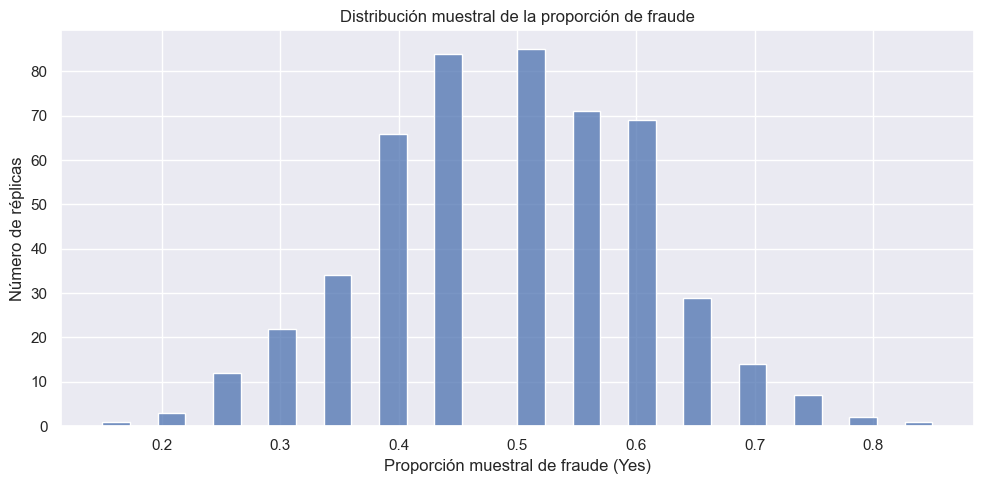

Análisis: la gráfica muestra la variabilidad de la proporción de casos de fraude en muestras de 20 transacciones.
Con n=20, el estimador de proporción aún tiene alta dispersión y cada réplica puede diferir notablemente.
Esto ilustra que, aunque la muestra refleja posible presencia de fraude, la estabilidad solo mejora con muchas réplicas o tamaños de muestra mayores.


In [11]:
sample_est = (
    samples500
    .groupby("replicate")["Fraud_Flag"]
    .value_counts(normalize=True)
    .reset_index(name="Proporción muestral")
)
sample_est_yes = sample_est[sample_est["Fraud_Flag"] == "Yes"].copy()

print("Distribución muestral de la proporción de fraude (Yes)")
print(sample_est_yes.head())

plt.figure(figsize=(10, 5))
sns.histplot(data=sample_est_yes, x="Proporción muestral", bins=30, kde=False, color="#4C72B0")
plt.title("Distribución muestral de la proporción de fraude")
plt.xlabel("Proporción muestral de fraude (Yes)")
plt.ylabel("Número de réplicas")
plt.tight_layout()
plt.show()

print("Análisis: la gráfica muestra la variabilidad de la proporción de casos de fraude en muestras de 20 transacciones.")
print("Con n=20, el estimador de proporción aún tiene alta dispersión y cada réplica puede diferir notablemente.")
print("Esto ilustra que, aunque la muestra refleja posible presencia de fraude, la estabilidad solo mejora con muchas réplicas o tamaños de muestra mayores.")

In [12]:
print("Estimador puntual de la proporción de fraude en las réplicas")
print(sample_est_yes["Proporción muestral"].mean())

print("\nProporción real de fraude en la población df_bancos")
print(df_bancos["Fraud_Flag"].value_counts(normalize=True))

Estimador puntual de la proporción de fraude en las réplicas
0.4915

Proporción real de fraude en la población df_bancos
Fraud_Flag
No     0.506959
Yes    0.493041
Name: proportion, dtype: float64


## Intervalo de confianza para la proporción de fraude

In [13]:
ci_data = pd.DataFrame(sample_est_yes["Proporción muestral"])
confidence = 0.95
df_t = len(ci_data) - 1
mean_prop = ci_data["Proporción muestral"].mean()
std_err = ci_data["Proporción muestral"].std(ddof=1) / np.sqrt(len(ci_data))
ci = stats.t.interval(confidence, df_t, loc=mean_prop, scale=std_err)

print("Intervalo de confianza 95% para la proporción de fraude (muestras)")
print(ci)
print("Análisis: el intervalo de confianza cuantifica la incertidumbre del estimador de proporción de fraude construido a partir de las réplicas.")
print("Se utiliza t de Student porque el estimador se basa en muestras y la desviación estándar se estima a partir de los datos.")
print("Si la proporción poblacional cae dentro del intervalo, la muestra es consistente con el comportamiento observado en toda la cartera.")

Intervalo de confianza 95% para la proporción de fraude (muestras)
(np.float64(0.48151709912879903), np.float64(0.501482900871201))
Análisis: el intervalo de confianza cuantifica la incertidumbre del estimador de proporción de fraude construido a partir de las réplicas.
Se utiliza t de Student porque el estimador se basa en muestras y la desviación estándar se estima a partir de los datos.
Si la proporción poblacional cae dentro del intervalo, la muestra es consistente con el comportamiento observado en toda la cartera.


## Distribución de Transaction_Amount en la población y en una muestra

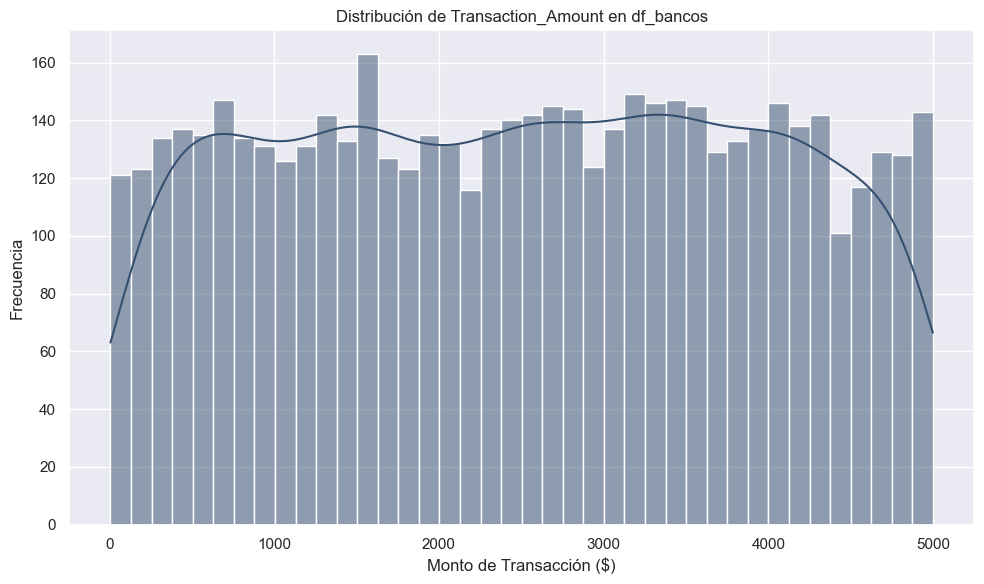

Análisis: el histograma de la población completa permite identificar la forma general de la distribución, su asimetría y los rangos de mayor concentración.
En este dataset, se puede comprobar si los montos se acumulan en un rango reducido o si existen colas largas hacia montos altos.
Esta visión es esencial para interpretar los resultados de muestreo y bootstrap con base en el comportamiento real de los datos.


In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_bancos, x="Transaction_Amount", bins=40, kde=True, color="#355070")
plt.title("Distribución de Transaction_Amount en df_bancos")
plt.xlabel("Monto de Transacción ($)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print("Análisis: el histograma de la población completa permite identificar la forma general de la distribución, su asimetría y los rangos de mayor concentración.")
print("En este dataset, se puede comprobar si los montos se acumulan en un rango reducido o si existen colas largas hacia montos altos.")
print("Esta visión es esencial para interpretar los resultados de muestreo y bootstrap con base en el comportamiento real de los datos.")

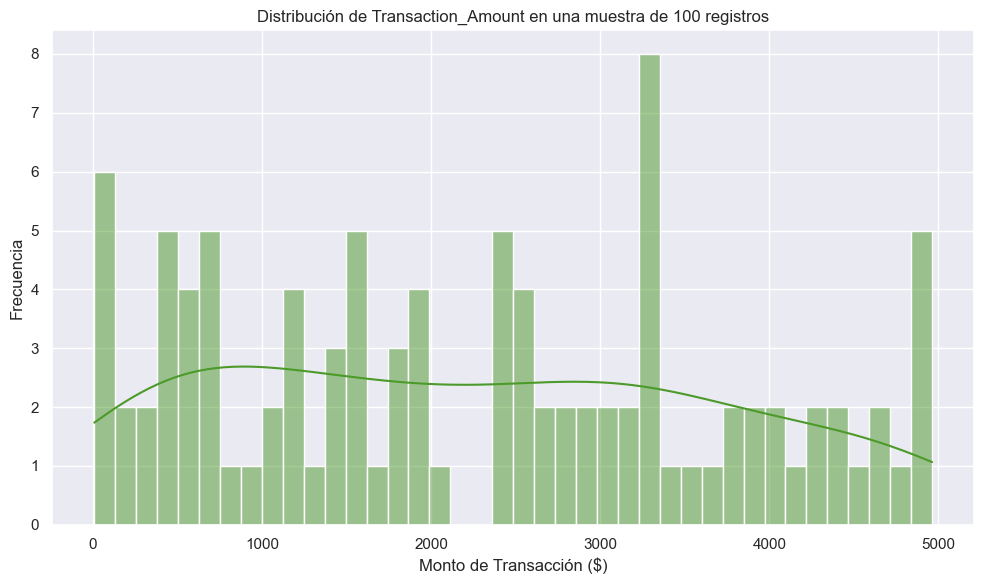

Análisis: la muestra de 100 registros preserva la forma global de la población pero introduce mayor ruido en los detalles locales.
Esta comparación entre población y muestra deja claro que un muestreo aislado puede parecer representativo, pero no captura todas las fluctuaciones reales.
Por eso es importante usar métodos de remuestreo como bootstrap y generar intervalos de confianza que describan la incertidumbre.
Media de la muestra de 100 registros: 2244.5015


In [17]:
df_bancos_one_sample = df_bancos.sample(n=100, random_state=123)
plt.figure(figsize=(10, 6))
sns.histplot(data=df_bancos_one_sample, x="Transaction_Amount", bins=40, kde=True, color="#4C9A2A")
plt.title("Distribución de Transaction_Amount en una muestra de 100 registros")
plt.xlabel("Monto de Transacción ($)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print("Análisis: la muestra de 100 registros preserva la forma global de la población pero introduce mayor ruido en los detalles locales.")
print("Esta comparación entre población y muestra deja claro que un muestreo aislado puede parecer representativo, pero no captura todas las fluctuaciones reales.")
print("Por eso es importante usar métodos de remuestreo como bootstrap y generar intervalos de confianza que describan la incertidumbre.")
print("Media de la muestra de 100 registros:", df_bancos_one_sample["Transaction_Amount"].mean())

## Distribución muestral de la media y la varianza de Transaction_Amount

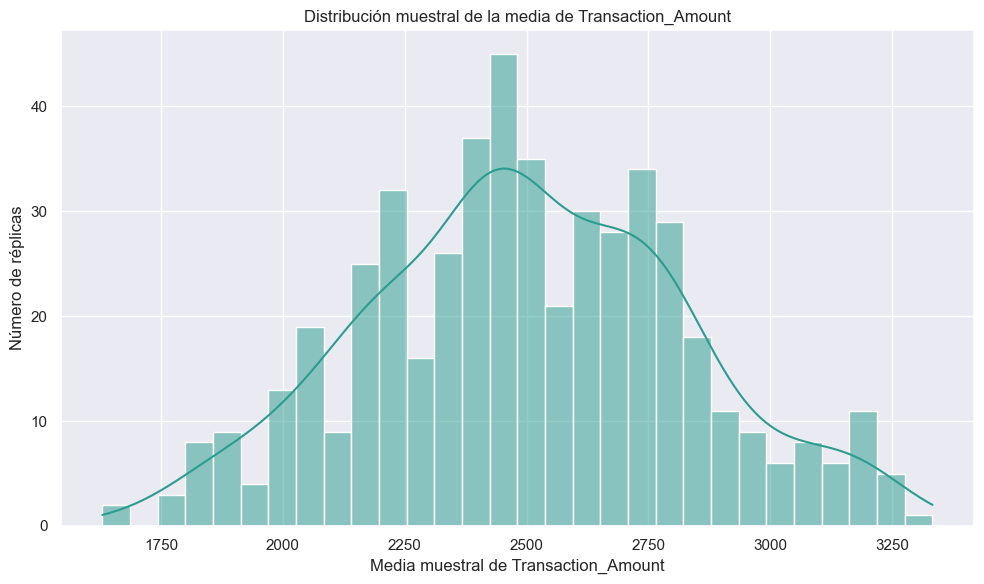

Análisis: la distribución de medias muestrales se concentra alrededor de un valor central, lo que ejemplifica la estabilidad del promedio frente a la variabilidad de las muestras.
Esta concentración es una forma práctica de observar el principio de estabilidad del estimador de la media.
Media de las medias muestrales: 2498.601295


In [18]:
trans_estimates = (
    samples500
    .groupby("replicate")["Transaction_Amount"]
    .mean()
    .reset_index(name="Transacciones")
)
plt.figure(figsize=(10, 6))
sns.histplot(data=trans_estimates, x="Transacciones", bins=30, kde=True, color="#2A9D8F")
plt.title("Distribución muestral de la media de Transaction_Amount")
plt.xlabel("Media muestral de Transaction_Amount")
plt.ylabel("Número de réplicas")
plt.tight_layout()
plt.show()

print("Análisis: la distribución de medias muestrales se concentra alrededor de un valor central, lo que ejemplifica la estabilidad del promedio frente a la variabilidad de las muestras.")
print("Esta concentración es una forma práctica de observar el principio de estabilidad del estimador de la media.")
print("Media de las medias muestrales:", trans_estimates["Transacciones"].mean())

In [19]:
data1 = pd.DataFrame(trans_estimates["Transacciones"])
df_t2 = len(data1) - 1
mean2 = data1["Transacciones"].mean()
std_err2 = data1["Transacciones"].std(ddof=1) / np.sqrt(len(data1))
ci2 = stats.t.interval(confidence, df_t2, loc=mean2, scale=std_err2)

print("Intervalo de confianza 95% de la media muestral:")
print(ci2)
print("Interpretación: el intervalo refleja cuán precisas son nuestras estimaciones de media cuando el muestreo se repite 500 veces.")

Intervalo de confianza 95% de la media muestral:
(np.float64(2469.692983248197), np.float64(2527.509606751803))
Interpretación: el intervalo refleja cuán precisas son nuestras estimaciones de media cuando el muestreo se repite 500 veces.


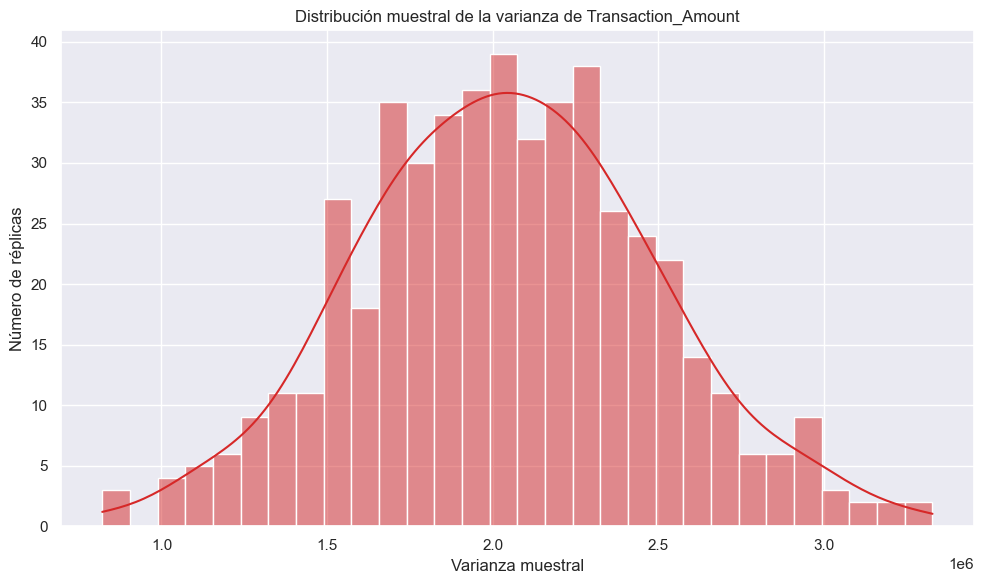

Análisis: la varianza muestral describe la dispersión de los estimadores entre réplicas y ayuda a evaluar cuánta incertidumbre tiene el cálculo del promedio.
Media de la varianza muestral: 2041517.8497833482
Varianza poblacional de Transaction_Amount (ddof=0): 2035223.8900259144


In [20]:
trans_estimates1 = (
    samples500
    .groupby("replicate")["Transaction_Amount"]
    .var()
    .reset_index(name="var_trans")
)
plt.figure(figsize=(10, 6))
sns.histplot(data=trans_estimates1, x="var_trans", bins=30, kde=True, color="#D62828")
plt.title("Distribución muestral de la varianza de Transaction_Amount")
plt.xlabel("Varianza muestral")
plt.ylabel("Número de réplicas")
plt.tight_layout()
plt.show()

print("Análisis: la varianza muestral describe la dispersión de los estimadores entre réplicas y ayuda a evaluar cuánta incertidumbre tiene el cálculo del promedio.")
print("Media de la varianza muestral:", trans_estimates1["var_trans"].mean())
print("Varianza poblacional de Transaction_Amount (ddof=0):", np.var(df_bancos["Transaction_Amount"], ddof=0))

In [23]:
data_var = pd.DataFrame(trans_estimates1["var_trans"])
alpha = 0.05
n = len(data_var)
var_mean = data_var["var_trans"].mean()
chi2_lower = stats.chi2.ppf(alpha / 2, df=n - 1)
chi2_upper = stats.chi2.ppf(1 - alpha / 2, df=n - 1)
ci_lower = (n - 1) * var_mean / chi2_upper
ci_upper = (n - 1) * var_mean / chi2_lower
print(f"Intervalo de confianza 95% de la varianza muestral: ({ci_lower:.4f}, {ci_upper:.4f})")
print("Interpretación: este intervalo demuestra la incertidumbre asociada al estimador de varianza sobre múltiples réplicas.")

Intervalo de confianza 95% de la varianza muestral: (1810121.5717, 2320551.2440)
Interpretación: este intervalo demuestra la incertidumbre asociada al estimador de varianza sobre múltiples réplicas.


## Bootstrap clásico y estimación empírica

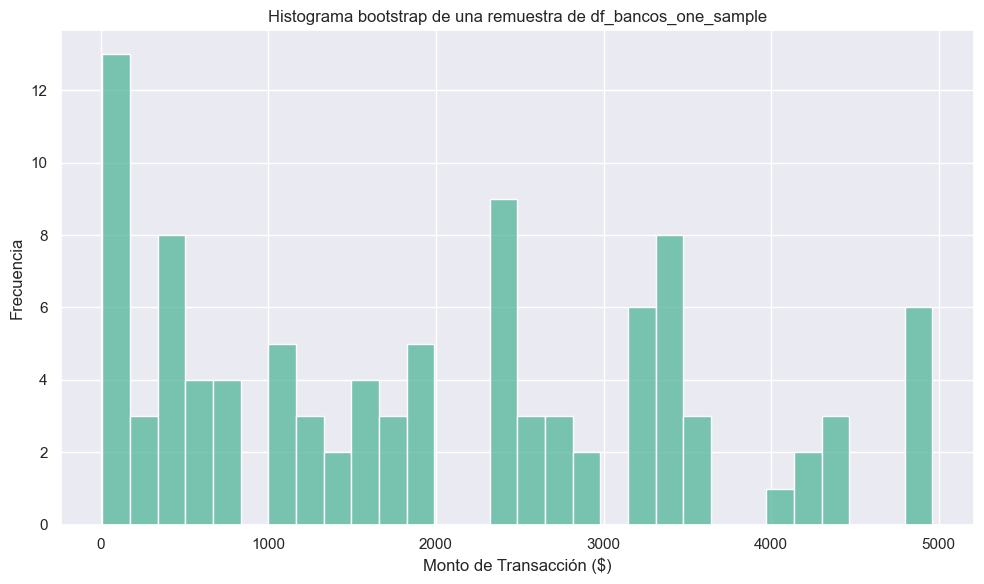

Análisis: la remuestra bootstrap reproduce la muestra base con reemplazo para estimar directamente la variabilidad del estadístico sin suponer una forma teórica.


In [24]:
boot_trans = df_bancos_one_sample.sample(frac=1, replace=True, random_state=123)
plt.figure(figsize=(10, 6))
sns.histplot(data=boot_trans, x="Transaction_Amount", bins=30, kde=False, color="#52B69A")
plt.title("Histograma bootstrap de una remuestra de df_bancos_one_sample")
plt.xlabel("Monto de Transacción ($)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print("Análisis: la remuestra bootstrap reproduce la muestra base con reemplazo para estimar directamente la variabilidad del estadístico sin suponer una forma teórica.")

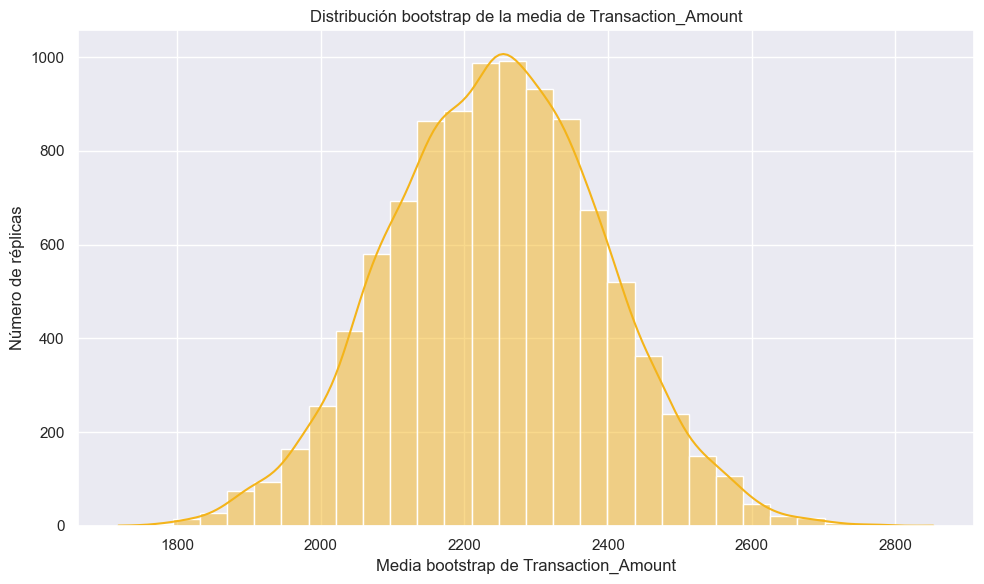

Análisis: la distribución bootstrap de medias muestra cómo el estimador cambia cuando repetimos la remuestreo 10,000 veces.
A diferencia del intervalo paramétrico, este enfoque empírico no asume normalidad en los montos de transacción.
Media bootstrap de 10,000 réplicas: 2244.44968683
Intervalo de confianza empírico bootstrap de la media:
0.025    1955.534972
0.975    2538.001745
Name: Transacciones, dtype: float64
Interpretación: el intervalo empírico bootstrap se calcula directamente desde la distribución de estadísticas bootstrap y refleja la variabilidad real observada.


In [25]:
boot_trans_10000 = pd.concat([
    df_bancos_one_sample.sample(frac=1, replace=True, random_state=123 + n).assign(replicate=n)
    for n in range(10000)
], ignore_index=True)

boot_charges_10000_means = (
    boot_trans_10000
    .groupby("replicate")["Transaction_Amount"]
    .mean()
    .reset_index(name="Transacciones")
)
plt.figure(figsize=(10, 6))
sns.histplot(data=boot_charges_10000_means, x="Transacciones", bins=30, kde=True, color="#F4B41A")
plt.title("Distribución bootstrap de la media de Transaction_Amount")
plt.xlabel("Media bootstrap de Transaction_Amount")
plt.ylabel("Número de réplicas")
plt.tight_layout()
plt.show()

print("Análisis: la distribución bootstrap de medias muestra cómo el estimador cambia cuando repetimos la remuestreo 10,000 veces.")
print("A diferencia del intervalo paramétrico, este enfoque empírico no asume normalidad en los montos de transacción.")
print("Media bootstrap de 10,000 réplicas:", boot_charges_10000_means["Transacciones"].mean())

ci_boot_charges = boot_charges_10000_means["Transacciones"].quantile([0.025, 0.975])
print("Intervalo de confianza empírico bootstrap de la media:")
print(ci_boot_charges)
print("Interpretación: el intervalo empírico bootstrap se calcula directamente desde la distribución de estadísticas bootstrap y refleja la variabilidad real observada.")

## Bootstrap del VaR 95% y comparación con el percentil poblacional

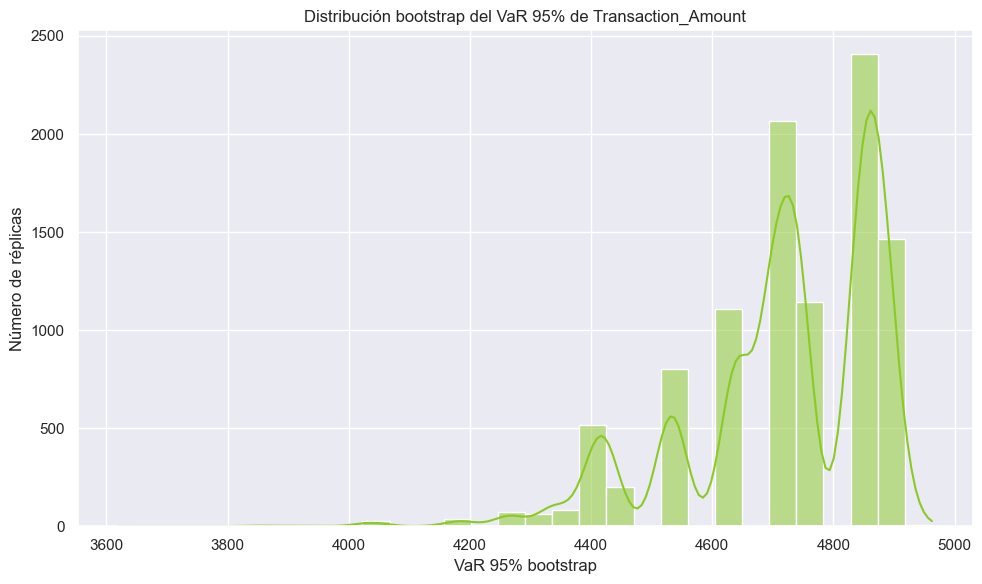

Análisis: el VaR bootstrap captura el valor extremo que no se supera en el 95% de las réplicas, lo cual es una estimación de riesgo de cola.
Esta métrica permite evaluar la exposición a montos altos y su consistencia frente a la variación muestral.
Media bootstrap del VaR 95%: 4717.4044616
Intervalo de confianza empírico bootstrap del VaR 95%:
0.025    4342.3485
0.975    4888.7805
Name: VaR_trans, dtype: float64
Percentil 95 real en la población df_bancos: 4751.092
Interpretación: comparar el VaR bootstrap con el percentil poblacional ayuda a ver si el método bootstrap reproduce correctamente el riesgo extremo observado en los datos completos.
Si hay discrepancia, puede indicar que la muestra base no es completamente representativa del comportamiento de cola de la población.


In [27]:
boot_trans_10000_VaR = (
    boot_trans_10000
    .groupby("replicate")["Transaction_Amount"]
    .quantile(0.95)
    .reset_index(name="VaR_trans")
)
plt.figure(figsize=(10, 6))
sns.histplot(data=boot_trans_10000_VaR, x="VaR_trans", bins=30, kde=True, color="#8AC926")
plt.title("Distribución bootstrap del VaR 95% de Transaction_Amount")
plt.xlabel("VaR 95% bootstrap")
plt.ylabel("Número de réplicas")
plt.tight_layout()
plt.show()

print("Análisis: el VaR bootstrap captura el valor extremo que no se supera en el 95% de las réplicas, lo cual es una estimación de riesgo de cola.")
print("Esta métrica permite evaluar la exposición a montos altos y su consistencia frente a la variación muestral.")
print("Media bootstrap del VaR 95%:", boot_trans_10000_VaR["VaR_trans"].mean())

ci_boot_trans_VaR = boot_trans_10000_VaR["VaR_trans"].quantile([0.025, 0.975])
print("Intervalo de confianza empírico bootstrap del VaR 95%:")
print(ci_boot_trans_VaR)

print("Percentil 95 real en la población df_bancos:", np.percentile(df_bancos["Transaction_Amount"], 95))

print("Interpretación: comparar el VaR bootstrap con el percentil poblacional ayuda a ver si el método bootstrap reproduce correctamente el riesgo extremo observado en los datos completos.")
print("Si hay discrepancia, puede indicar que la muestra base no es completamente representativa del comportamiento de cola de la población.")